# FAA Wildlife Strikes: Exploratory Data Analysis


### Main project question
> **What makes a wildlife strike damaging, and when, where, and with which animals is the risk highest?**

Every chart below answers one sub-question of this main question and ends with an **insight** and an **EDA decision**

| # | Sub-question | Visual |
|---|---|---|
| 1 | How rare are damaging strikes? | Class balance + train/test drift |
| 2 | Are strikes really getting more frequent? | Annual counts vs. damage rate |
| 3 | When do strikes happen? | Month × hour heatmap |
| 4 | Which phase of flight is riskiest? | Counts + damage rate by phase |
| 5 | Does altitude matter? | Counts + damage rate by height band |
| 6 | Does the animal's size / flock size matter? | Damage-rate heatmap (size × number struck) |
| 7 | Which species are the most dangerous? | Species risk matrix |
| 8 | Which aircraft parts get hit and damaged? | Struck vs. damaged components |
| 9 | Is missing data random? | Damage rate: reported vs. missing |
| 10 | Which features best separate damaging strikes? | Cramér's V feature ranking |
| 11 | Where do strikes happen? | U.S. state map (interactive) |
| 12 | Does GPU acceleration help our EDA? | RAPIDS cuDF vs. pandas benchmark |

> **Data note.** This notebook uses the same cleaned file as the Tableau dashboard (`clean_wildlife.parquet`, converted from the dashboard's `clean_wildlife (1).csv`). Of 356,920 strikes, **126,092 were never assessed for damage** (`DAMAGE_LEVEL = Unknown`). They still count as strikes, but they are **left out of every damage rate**, because "never checked" is not the same as "no damage". Damage rates are therefore based on the **230,828 assessed strikes** (overall rate **9.6%**), exactly as in the dashboard and the modeling data.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Setup

In [7]:
!pip install -q adjustText
import os, sys, json, shutil, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
warnings.filterwarnings("ignore")

if "clean_df" in globals():
    eda = clean_df.copy()
    print("Using clean_df from the cleaning notebook (same session).")
elif os.path.exists("clean_wildlife.parquet"):
    eda = pd.read_parquet("clean_wildlife.parquet")
    print("Loaded clean_wildlife.parquet")
elif os.path.exists("clean_wildlife.csv"):
    eda = pd.read_csv("clean_wildlife.csv", low_memory=False)
    print("Loaded clean_wildlife.csv")
else:
    raise FileNotFoundError(
        "Run the cleaning notebook first, or save its output with "
        "clean_df.to_parquet('clean_wildlife.parquet') and upload the file.")

# ---------- Damage target: assessed strikes only ----------
# Same definition as the updated cleaning notebook and the Tableau dashboard:
# strikes whose DAMAGE_LEVEL is "Unknown" were never inspected, so they cannot count as "no damage".
# They stay in the data (they still count as strikes), but are left out of every damage rate.
eda["DAMAGE_TARGET"] = pd.to_numeric(eda["DAMAGE_TARGET"], errors="coerce").astype(float)
if "DAMAGE_LEVEL" in eda:
    lvl = eda["DAMAGE_LEVEL"].astype("string").str.strip().str.lower()
    eda.loc[lvl.isna() | lvl.isin(["unknown", "", "nan", "<na>"]), "DAMAGE_TARGET"] = np.nan
N_ALL, N_ASSESSED = len(eda), int(eda["DAMAGE_TARGET"].notna().sum())
print(f"{N_ALL:,} strikes x {eda.shape[1]} columns · {N_ASSESSED:,} assessed for damage "
      f"({N_ALL - N_ASSESSED:,} never assessed: kept as strikes, excluded from damage rates)")

NAVY, RED, GOLD, TEAL, GREY = "#1B3A5C", "#D1495B", "#EDAE49", "#00798C", "#A0AAB4"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 11, "font.size": 11,
})
os.makedirs("figures", exist_ok=True)

def save(fig, name):
    """Save every figure for the slide deck."""
    fig.savefig(f"figures/{name}.png", dpi=200, bbox_inches="tight")

def finding(text):
    print("📌 " + text)

def is_unknown(s):
    s = s.astype("string").str.strip().str.lower()
    return s.isna() | s.isin(["unknown", "", "nan", "<na>"])

BASE_RATE = eda["DAMAGE_TARGET"].mean()
pct = mtick.PercentFormatter(xmax=1, decimals=0)
thousands = mtick.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k" if v >= 1000 else f"{v:,.0f}")
print(f"Overall damage rate (assessed strikes): {BASE_RATE:.2%}")

Loaded clean_wildlife.parquet
356,920 strikes x 102 columns · 230,828 assessed for damage (126,092 never assessed: kept as strikes, excluded from damage rates)
Overall damage rate (assessed strikes): 9.64%


In [8]:
# ---------- Helper features used throughout the EDA ----------
year_col = "CALCULATED_YEAR" if "CALCULATED_YEAR" in eda else "INCIDENT_YEAR"
eda["YEAR"] = pd.to_numeric(eda[year_col], errors="coerce")
month_col = "CALCULATED_MONTH" if "CALCULATED_MONTH" in eda else "INCIDENT_MONTH"
eda["MONTH"] = pd.to_numeric(eda[month_col], errors="coerce")

# Hour of day from TIME (e.g. "14:35" or "1435")
t = eda["TIME"].astype("string").str.strip()
hh = t.str.extract(r"^(\d{1,2}):")[0].fillna(t.str.extract(r"^(\d{3,4})$")[0].str[:-2])
eda["HOUR"] = pd.to_numeric(hh, errors="coerce")
eda.loc[~eda["HOUR"].between(0, 23), "HOUR"] = np.nan

# Height bands (feet above ground level)
h_bins   = [-np.inf, 0, 100, 500, 1000, 3000, 5000, np.inf]
h_labels = ["Ground (0)", "1–100", "101–500", "501–1,000", "1,001–3,000", "3,001–5,000", "5,000+"]
eda["HEIGHT_BAND"] = pd.cut(eda["HEIGHT"], h_bins, labels=h_labels).astype("string").fillna("Not reported")

# Speed bands (knots)
eda["SPEED_BAND"] = pd.cut(eda["SPEED"], [-np.inf, 100, 140, 180, np.inf],
                           labels=["<100", "100–140", "141–180", ">180"]).astype("string").fillna("Not reported")

# Number of animals struck -> standard FAA ranges
def struck_bin(col):
    s = eda[col].astype("string").str.strip().str.upper()
    text_map = {"1": "1", "2 TO 10": "2–10", "2-10": "2–10", "11 TO 100": "11–100",
                "11-100": "11–100", "OVER 100": "100+", "MORE THAN 100": "100+"}
    if s.isin(["2 TO 10", "2-10", "11 TO 100", "11-100", "OVER 100", "MORE THAN 100"]).any():
        return s.map(text_map).fillna("Unknown")
    n = pd.to_numeric(s, errors="coerce")
    return pd.cut(n, [0, 1, 10, 100, np.inf], labels=["1", "2–10", "11–100", "100+"]).astype("string").fillna("Unknown")
eda["STRUCK_BIN"] = struck_bin("NUM_STRUCK")

# Tidy category spellings
eda["PHASE"] = eda["PHASE_OF_FLIGHT"].astype("string").str.strip().str.title()
eda["SIZE_C"] = eda["SIZE"].astype("string").str.strip().str.title()
eda["SPECIES_KNOWN"] = ~eda["SPECIES"].astype("string").str.lower().str.contains("unknown", na=True)

cost_cols = [c for c in ["COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ"] if c in eda]
eda["TOTAL_COST"] = eda[cost_cols].sum(axis=1, min_count=1)

print(eda[["YEAR", "MONTH", "HOUR", "HEIGHT_BAND", "SPEED_BAND", "STRUCK_BIN", "PHASE", "SIZE_C"]].head())

   YEAR  MONTH  HOUR  HEIGHT_BAND    SPEED_BAND STRUCK_BIN         PHASE  \
0  1996      6  <NA>   Ground (0)  Not reported          1  Take-Off Run   
1  1996      6  <NA>   Ground (0)  Not reported          1  Take-Off Run   
2  1996      7  <NA>   Ground (0)  Not reported          1  Take-Off Run   
3  1996      7  <NA>    501–1,000  Not reported          1      Approach   
4  1996      7  <NA>  3,001–5,000  Not reported          1         Climb   

   SIZE_C  
0  Medium  
1  Medium  
2  Medium  
3  Medium  
4  Medium  


## 1. How rare are damaging strikes?
*Why it matters:* the target variable for our ML direction is `DAMAGE_TARGET`. If it is heavily imbalanced, plain accuracy is meaningless and we need special handling.

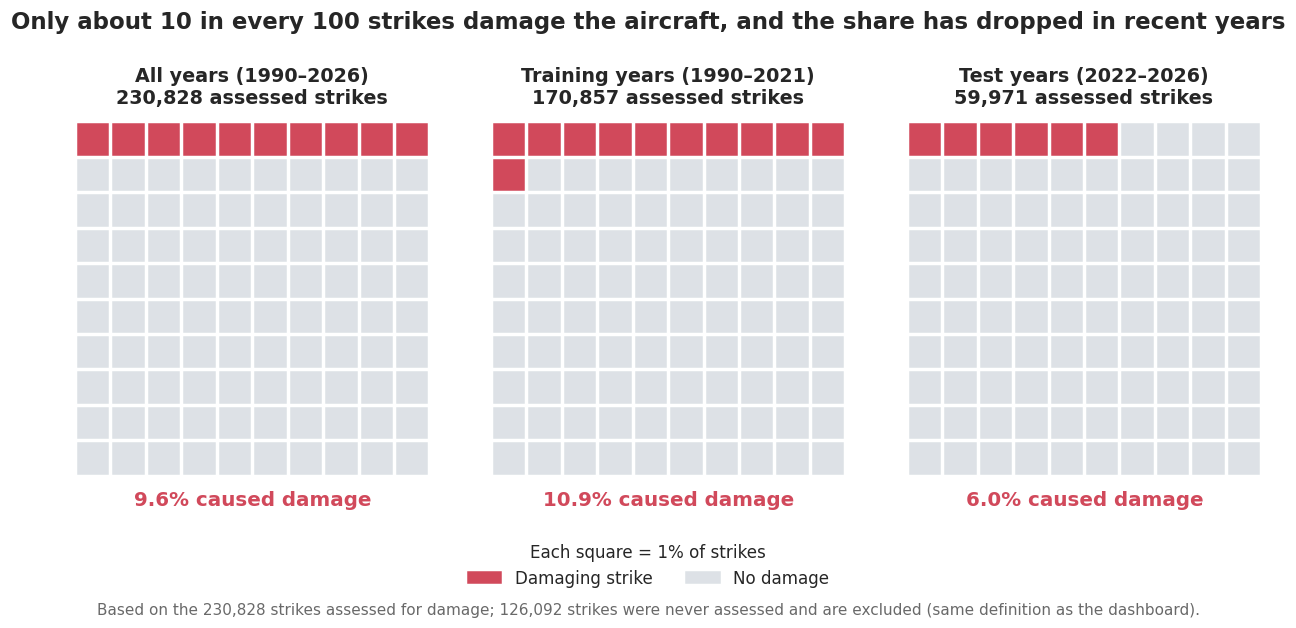

📌 22,256 damaging vs 208,572 non-damaging strikes: 1 damaging for every 9 non-damaging, i.e. about 1 in 10 strikes overall.
📌 A model that always predicts 'no damage' would score 90.4% accuracy while catching zero damaging strikes.
📌 Damage rate: 10.92% in the training years vs 5.99% in the test years (about 1.8x lower recently, a distribution drift).


In [9]:
split_year = 2022   # same time-based split as the cleaning notebook
counts = eda["DAMAGE_TARGET"].value_counts().reindex([0, 1])
train = eda[eda["YEAR"] < split_year]
test  = eda[eda["YEAR"] >= split_year]
train_rate, test_rate = train["DAMAGE_TARGET"].mean(), test["DAMAGE_TARGET"].mean()
y0, y1 = int(eda["YEAR"].min()), int(eda["YEAR"].max())
LIGHT = "#DDE1E6"

def waffle(ax, rate, n_strikes, title):
    """10 x 10 grid: each square = 1% of strikes; red squares = damaging strikes."""
    n_red = int(round(rate * 100))
    for i in range(100):
        row, col = divmod(i, 10)
        ax.add_patch(plt.Rectangle((col, 9 - row), .86, .86, color=RED if i < n_red else LIGHT))
    ax.set_xlim(-.2, 10); ax.set_ylim(-1.6, 10.2); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{title}\n{n_strikes:,} assessed strikes", loc="center", fontsize=12.5, fontweight="bold")
    ax.text(4.93, -.9, f"{rate:.1%} caused damage", ha="center", fontsize=13, fontweight="bold", color=RED)

fig, axes = plt.subplots(1, 3, figsize=(14, 5.6))
waffle(axes[0], BASE_RATE, N_ASSESSED, f"All years ({y0}–{y1})")
waffle(axes[1], train_rate, int(train["DAMAGE_TARGET"].notna().sum()), f"Training years ({y0}–{split_year - 1})")
waffle(axes[2], test_rate, int(test["DAMAGE_TARGET"].notna().sum()), f"Test years ({split_year}–{y1})")

fig.suptitle(f"Only about {round(BASE_RATE * 100)} in every 100 strikes damage the aircraft, "
             "and the share has dropped in recent years", fontsize=15, fontweight="bold", y=1.0)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=RED, label="Damaging strike"), Patch(color=LIGHT, label="No damage")],
           title="Each square = 1% of strikes", loc="upper center", bbox_to_anchor=(.5, .16),
           ncol=2, frameon=False, fontsize=11, title_fontsize=11)
fig.text(.5, .02, f"Based on the {N_ASSESSED:,} strikes assessed for damage; {N_ALL - N_ASSESSED:,} strikes were never "
         "assessed and are excluded (same definition as the dashboard).", ha="center", fontsize=10, color="dimgray")
fig.subplots_adjust(wspace=.15)
save(fig, "01_class_imbalance"); plt.show()

finding(f"{counts[1]:,} damaging vs {counts[0]:,} non-damaging strikes: 1 damaging for every "
        f"{counts[0]/counts[1]:.0f} non-damaging, i.e. about 1 in {1/BASE_RATE:.0f} strikes overall.")
finding(f"A model that always predicts 'no damage' would score {1-BASE_RATE:.1%} accuracy "
        "while catching zero damaging strikes.")
finding(f"Damage rate: {train_rate:.2%} in the training years vs {test_rate:.2%} in the test years "
        f"(about {train_rate/test_rate:.1f}x lower recently, a distribution drift).")

**Insight:** Of the 230,828 strikes assessed for damage, **9.6%** caused damage (about 1 in 10). A model that always predicts "no damage" would be **90.4% accurate** yet catch zero damaging strikes. The rate also **nearly halved** over time, from **10.9%** in the training years (1990–2021) to **6.0%** in the test years (2022 onward).

**EDA decision:**
- Binary classification with **class weights or SMOTE** (training set only).
- Evaluate with **PR-AUC, recall and F1**, not accuracy.
- Keep the **time-based split** and **tune the decision threshold** to account for the drift.

## 2. Are strikes really getting more frequent?
*Why it matters:* raw counts can reflect better **reporting** rather than more danger. We need to know which one we are looking at before drawing conclusions.

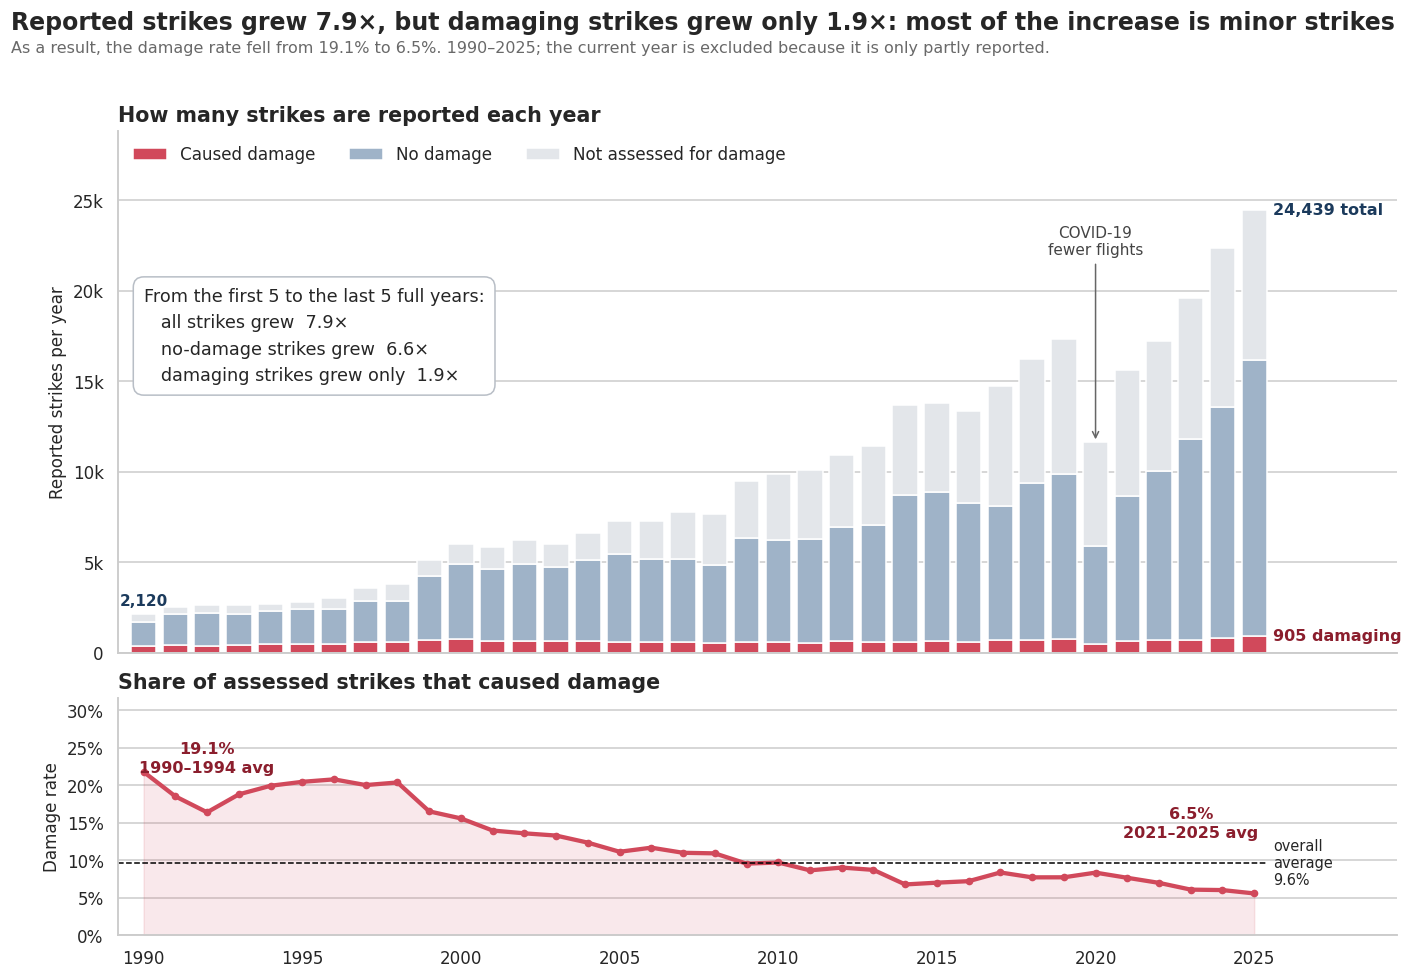

📌 Strikes grew 7.9x from the first 5 to the last 5 full years (no-damage strikes 6.6x, damaging strikes 1.9x).
📌 Damage rate fell from 19.1% to 6.5% over the same period.


In [10]:
# ---------- Section 2: are strikes really getting more frequent? ----------
yearly = eda.groupby("YEAR").agg(strikes=("DAMAGE_TARGET", "size"), damaged=("DAMAGE_TARGET", "sum"),
                                 assessed=("DAMAGE_TARGET", "count"), rate=("DAMAGE_TARGET", "mean"))
last_full = int(yearly.index.max()) - 1                   # the current year is only partly reported
yearly = yearly.loc[:last_full]
yearly["undamaged"] = yearly["assessed"] - yearly["damaged"]       # assessed, no damage
yearly["unassessed"] = yearly["strikes"] - yearly["assessed"]     # never assessed
first5, last5 = yearly.head(5), yearly.tail(5)
g_all = last5["strikes"].mean() / first5["strikes"].mean()
g_dmg = last5["damaged"].mean() / first5["damaged"].mean()
g_ok = last5["undamaged"].mean() / first5["undamaged"].mean()
LIGHT_NAVY = "#9FB3C8"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1], "hspace": .12})
x = yearly.index.values

# ---- TOP: stacked bars - damaging strikes (red) at the bottom, no-damage strikes (light navy) on top ----
ax1.bar(x, yearly["damaged"], color=RED, width=.8, label="Caused damage")
ax1.bar(x, yearly["undamaged"], bottom=yearly["damaged"], color=LIGHT_NAVY, width=.8, label="No damage")
ax1.bar(x, yearly["unassessed"], bottom=yearly["damaged"] + yearly["undamaged"], color="#E3E6EA", width=.8,
        label="Not assessed for damage")
ax1.yaxis.set_major_formatter(thousands); ax1.set_ylabel("Reported strikes per year")
ax1.grid(axis="x", visible=False)
ax1.legend(loc="upper left", frameon=False, fontsize=11, ncol=3)
ax1.set_ylim(0, yearly["strikes"].max() * 1.18)
ax1.set_title("How many strikes are reported each year", fontsize=13.5, loc="left")
# start / end labels: total strikes and damaging strikes
r0, r1 = yearly.iloc[0], yearly.iloc[-1]
ax1.text(x[0], r0["strikes"] + yearly["strikes"].max() * .02, f"{r0['strikes']:,.0f}", ha="center", fontsize=10,
         fontweight="bold", color=NAVY)
ax1.text(x[-1] + .6, r1["strikes"], f"{r1['strikes']:,.0f} total", va="center", fontsize=10.5, fontweight="bold", color=NAVY)
ax1.text(x[-1] + .6, r1["damaged"], f"{r1['damaged']:,.0f} damaging", va="center", fontsize=10.5, fontweight="bold",
         color="#8B1E2D")
# COVID note, placed above the 2020 bar so it doesn't cross other bars
if 2020 in yearly.index:
    ax1.annotate("COVID-19\nfewer flights", xy=(2020, yearly.loc[2020, "strikes"]),
                 xytext=(2020, yearly["strikes"].max() * .9), ha="center", fontsize=10, color="#444444",
                 arrowprops=dict(arrowstyle="->", color="#666666", lw=1))
# key-numbers box
ax1.text(.02, .7, f"From the first 5 to the last 5 full years:\n"
                  f"   all strikes grew  {g_all:.1f}×\n"
                  f"   no-damage strikes grew  {g_ok:.1f}×\n"
                  f"   damaging strikes grew only  {g_dmg:.1f}×",
         transform=ax1.transAxes, fontsize=11.5, va="top", linespacing=1.6, family="DejaVu Sans",
         bbox=dict(boxstyle="round,pad=.6", fc="white", ec="#B8BEC6"))

# ---- BOTTOM: damage rate over time ----
ax2.fill_between(x, yearly["rate"], color=RED, alpha=.12)
ax2.plot(x, yearly["rate"], color=RED, lw=2.8, marker="o", ms=4)
ax2.hlines(BASE_RATE, x[0] - .8, x[-1] + .4, color="black", ls="--", lw=1)
ax2.text(x[-1] + .6, BASE_RATE, f"overall\naverage\n{BASE_RATE:.1%}", va="center", fontsize=9.5, linespacing=1.2)
for grp, yr_lab, ha in [(first5, first5.index.values.mean(), "center"), (last5, last5.index.values.mean(), "center")]:
    ax2.text(yr_lab, grp["rate"].mean() + yearly["rate"].max() * (.12 if grp is first5 else .3),
             f"{grp['rate'].mean():.1%}\n{int(grp.index.min())}–{int(grp.index.max())} avg", ha=ha, fontsize=10.5,
             fontweight="bold", color="#8B1E2D", linespacing=1.3)
ax2.set_ylim(0, yearly["rate"].max() * 1.45)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.set_ylabel("Damage rate")
ax2.grid(axis="x", visible=False)
ax2.set_title("Share of assessed strikes that caused damage", fontsize=13.5, loc="left")
ax2.set_xlim(x[0] - .8, x[-1] + 4.5)

fig.suptitle(f"Reported strikes grew {g_all:.1f}×, but damaging strikes grew only {g_dmg:.1f}×: "
             "most of the increase is minor strikes", fontsize=15.5, fontweight="bold", x=.06, ha="left", y=.995)
fig.text(.06, .955, f"As a result, the damage rate fell from {first5['rate'].mean():.1%} to {last5['rate'].mean():.1%}. "
         f"{int(x[0])}–{last_full}; the current year is excluded because it is only partly reported.",
         fontsize=10.5, color="dimgray")
save(fig, "02_annual_trend"); plt.show()

finding(f"Strikes grew {g_all:.1f}x from the first 5 to the last 5 full years "
        f"(no-damage strikes {g_ok:.1f}x, damaging strikes {g_dmg:.1f}x).")
finding(f"Damage rate fell from {first5['rate'].mean():.1%} to {last5['rate'].mean():.1%} over the same period.")

**Insight:** Reported strikes grew **7.9×** from the early 1990s to the last five years, but **damaging strikes grew only 1.9×**. Most of the growth is **minor strikes** (assessed no-damage strikes grew 6.6×) and strikes **never assessed for damage** (the light grey part, which has grown sharply in recent years). As a result, the damage rate fell from **19.1%** (1990–1994) to **6.5%** (2021–2025). This points to **more complete reporting of minor strikes**, on top of real growth in air traffic. The 2020 dip lines up with the pandemic drop in flights.

**EDA decision:**
- Compare groups using **damage rates**, not raw counts, throughout the analysis.
- The partly reported current year is excluded from trend charts.
- This drift supports the **time-based train/test split**; `YEAR` will be used with caution since it partly reflects reporting behavior.

## 3. When do strikes happen?
*Why it matters:* timing tells airports **when** to step up wildlife control, and season and hour are candidate model features.

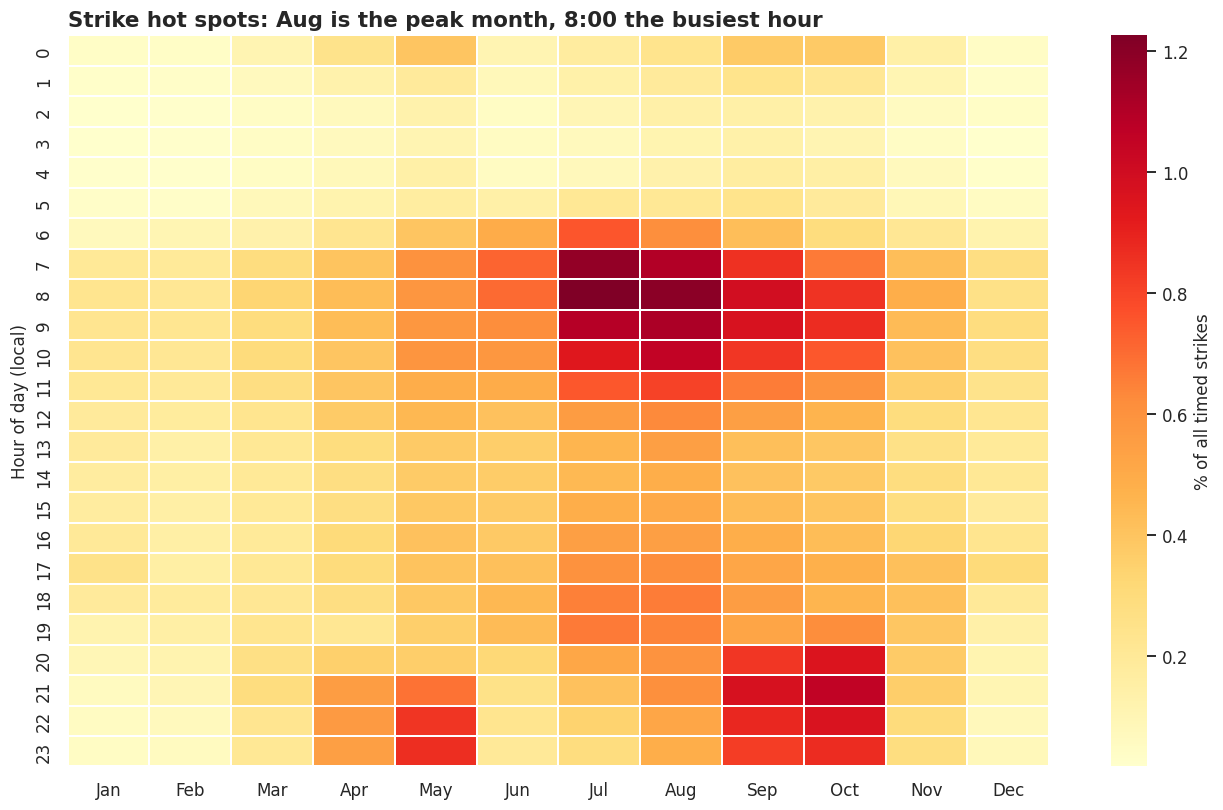

📌 Peak month: Aug. Jul–Oct hold 52% of all strikes (an even spread would be 33%).
📌 Busiest hour: 8:00. Hour is known for 57% of strikes.


In [11]:
timed = eda.dropna(subset=["HOUR", "MONTH"])
heat = pd.crosstab(timed["HOUR"].astype(int), timed["MONTH"].astype(int), normalize=True) * 100
heat = heat.reindex(index=range(24), columns=range(1, 13), fill_value=0)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

by_month = eda["MONTH"].value_counts(normalize=True).sort_index()
peak_month = int(by_month.idxmax()); peak_hour = int(timed["HOUR"].value_counts().idxmax())
fig, ax = plt.subplots(figsize=(12, 7.5))
sns.heatmap(heat, cmap="YlOrRd", ax=ax, cbar_kws={"label": "% of all timed strikes"},
            xticklabels=month_names, linewidths=.3, linecolor="white")
ax.set_xlabel(""); ax.set_ylabel("Hour of day (local)")
ax.set_title(f"Strike hot spots: {month_names[peak_month-1]} is the peak month, {peak_hour}:00 the busiest hour")
fig.tight_layout(); save(fig, "03_month_hour_heatmap"); plt.show()

finding(f"Peak month: {month_names[peak_month-1]}. Jul–Oct hold {by_month.loc[7:10].sum():.0%} of all strikes "
        f"(an even spread would be 33%).")
finding(f"Busiest hour: {peak_hour}:00. Hour is known for {len(timed)/len(eda):.0%} of strikes.")

**Insight:** Strikes cluster from **July to October** (52% of all strikes, with **August** the peak), which matches the season when young birds leave the nest and fall migration begins. Within the day, the pattern reflects both bird activity and flight schedules.

**EDA decision:**
- Keep `MONTH`/`SEASON` and `HOUR`/`TIME_OF_DAY` as candidate features.
- Because about a third of strikes lack a time, keep **"Unknown" as its own category** rather than dropping those rows.
- This heatmap is a strong candidate for a filterable view in the dashboard.

## 4. Which phase of flight is riskiest?
*Why it matters:* frequency and danger are not the same thing. A phase can have many strikes but few damaging ones.

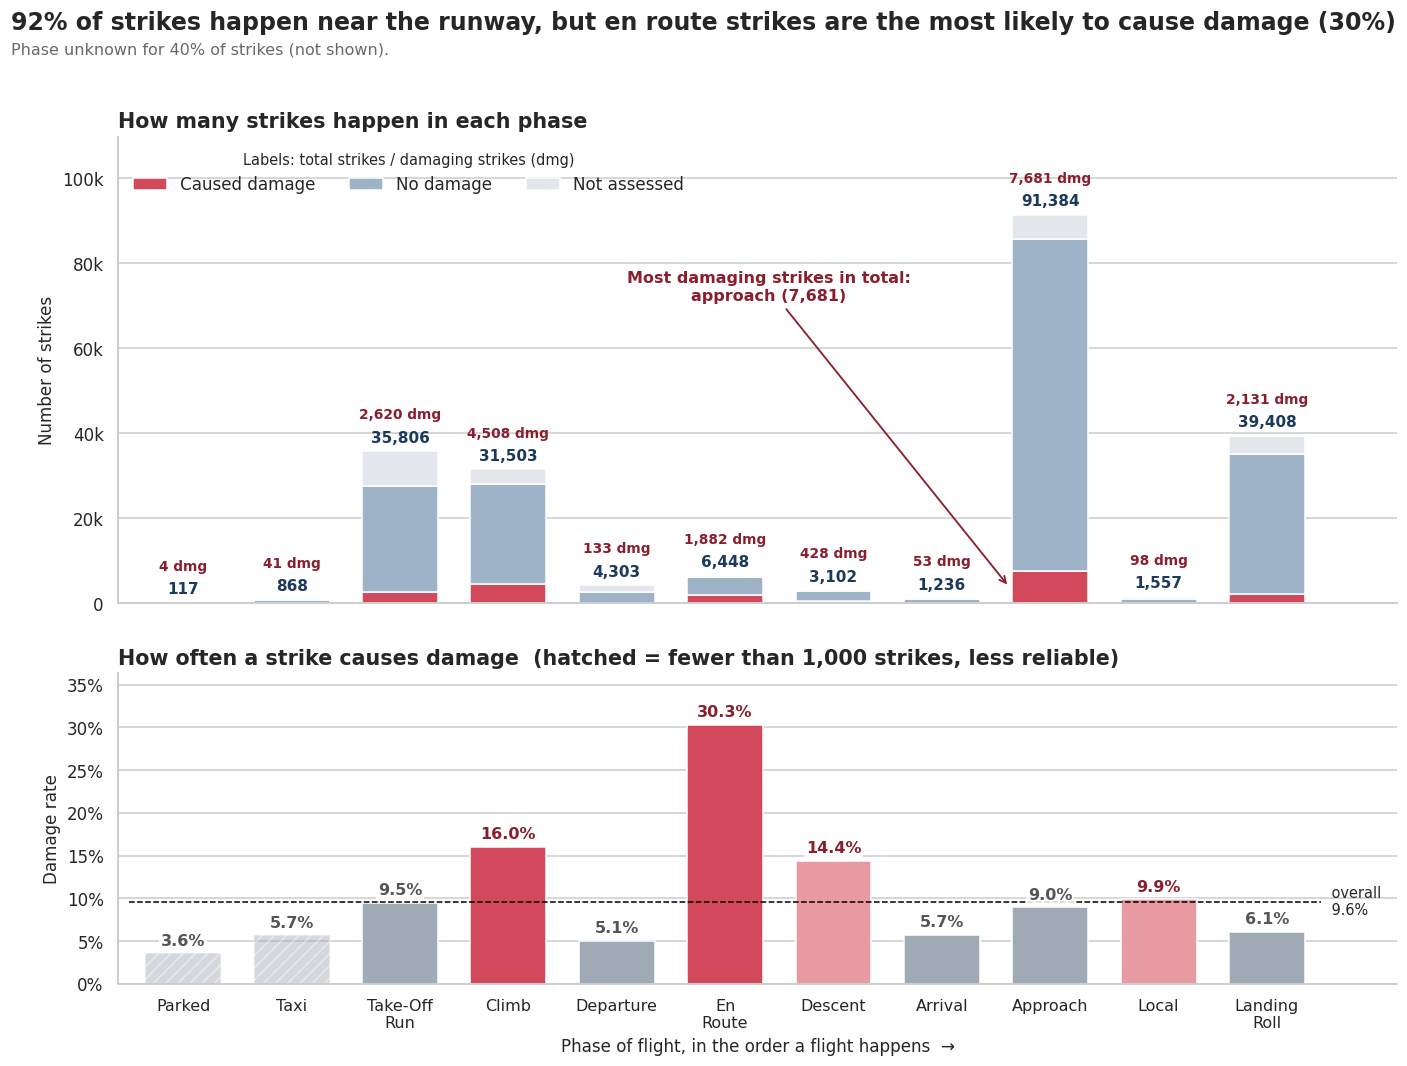

📌 Take-off run, climb, approach and landing roll account for 92% of strikes with a known phase.
📌 Highest damage rate: En Route (30.3%); most damaging strikes in total: Approach (7,681).
📌 Phase is unknown for 40% of strikes (excluded from this chart).


In [12]:
# ---------- Section 4 (bar version): strikes and damage by phase of flight ----------
known = eda[~is_unknown(eda["PHASE"])]
ph = known.groupby("PHASE")["DAMAGE_TARGET"].agg(strikes="size", damaged="sum", assessed="count", rate="mean")
order = ["Parked", "Taxi", "Take-Off Run", "Climb", "Departure", "En Route", "Descent", "Arrival", "Approach",
         "Local", "Landing Roll"]
ph = ph.reindex([p for p in order if p in ph.index] + [p for p in ph.index if p not in order])
ph["undamaged"] = ph["assessed"] - ph["damaged"]
ph["unassessed"] = ph["strikes"] - ph["assessed"]
SMALL_N = 1000                                            # phases with fewer strikes: rate less reliable
x = np.arange(len(ph)); labels = [p.replace(" ", "\n") for p in ph.index]
LIGHT_NAVY = "#9FB3C8"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [1.5, 1], "hspace": .18})

# ---- TOP: stacked bars - damaging (red) + no damage (light navy) ----
ax1.bar(x, ph["damaged"], color=RED, width=.7, label="Caused damage")
ax1.bar(x, ph["undamaged"], bottom=ph["damaged"], color=LIGHT_NAVY, width=.7, label="No damage")
ax1.bar(x, ph["unassessed"], bottom=ph["damaged"] + ph["undamaged"], color="#E3E6EA", width=.7,
        label="Not assessed")
for xi, (p, r) in zip(x, ph.iterrows()):                  # total on top, damaging count (red) just below it
    ax1.text(xi, r["strikes"] + ph["strikes"].max() * .015, f"{int(r['strikes']):,}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color=NAVY)
    ax1.text(xi, r["strikes"] + ph["strikes"].max() * .075, f"{int(r['damaged']):,} dmg", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#8B1E2D")
top_dmg = ph["damaged"].idxmax()
ax1.annotate(f"Most damaging strikes in total:\n{top_dmg.lower()} ({int(ph.loc[top_dmg, 'damaged']):,})",
             xy=(list(ph.index).index(top_dmg) - .38, ph.loc[top_dmg, "damaged"] / 2),
             xytext=(list(ph.index).index(top_dmg) - 2.6, ph["strikes"].max() * .78), fontsize=10.5, fontweight="bold",
             color="#8B1E2D", ha="center", arrowprops=dict(arrowstyle="->", color="#8B1E2D", lw=1.2))
ax1.set_ylim(0, ph["strikes"].max() * 1.2)
ax1.yaxis.set_major_formatter(thousands); ax1.set_ylabel("Number of strikes")
ax1.grid(axis="x", visible=False); ax1.legend(loc="upper left", frameon=False, fontsize=11, ncol=3,
                                              title="Labels: total strikes / damaging strikes (dmg)", title_fontsize=9.5)
ax1.set_title("How many strikes happen in each phase", fontsize=13.5, loc="left")

# ---- BOTTOM: damage rate per phase (separate bars, no connecting line) ----
cols = [RED if r > BASE_RATE * 1.5 else ("#E89AA3" if r > BASE_RATE else GREY) for r in ph["rate"]]
bars = ax2.bar(x, ph["rate"], color=cols, width=.7)
for b, n in zip(bars, ph["strikes"]):
    if n < SMALL_N: b.set_alpha(.45); b.set_hatch("///")
for xi, (r, n) in zip(x, zip(ph["rate"], ph["strikes"])):
    ax2.text(xi, r + ph["rate"].max() * .02, f"{r:.1%}", ha="center", va="bottom", fontsize=10.5, fontweight="bold",
             color="#8B1E2D" if r > BASE_RATE else "#555555", bbox=dict(fc="white", ec="none", pad=1, alpha=.85))
ax2.hlines(BASE_RATE, -.5, len(ph) - .5, color="black", ls="--", lw=1)
ax2.text(len(ph) - .45, BASE_RATE, f" overall\n {BASE_RATE:.1%}", va="center", fontsize=9.5)
ax2.set_ylim(0, ph["rate"].max() * 1.2); ax2.set_xlim(-.6, len(ph) + .2)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0)); ax2.set_ylabel("Damage rate")
ax2.grid(axis="x", visible=False)
ax2.set_title(f"How often a strike causes damage  (hatched = fewer than {SMALL_N:,} strikes, less reliable)",
              fontsize=13.5, loc="left")
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=10.5)
ax2.set_xlabel("Phase of flight, in the order a flight happens  →", fontsize=11)

near = ph.loc[[p for p in ["Take-Off Run", "Climb", "Approach", "Landing Roll"] if p in ph.index], "strikes"].sum()
top_r = ph.loc[ph["strikes"] >= SMALL_N, "rate"].idxmax()
fig.suptitle(f"{near / ph['strikes'].sum():.0%} of strikes happen near the runway, but {top_r.lower()} strikes are the most "
             f"likely to cause damage ({ph.loc[top_r, 'rate']:.0%})", fontsize=15.5, fontweight="bold", x=.06, ha="left", y=.995)
fig.text(.06, .955, f"Phase unknown for {is_unknown(eda['PHASE']).mean():.0%} of strikes (not shown).", fontsize=10.5,
         color="dimgray")
save(fig, "04_phase_of_flight"); plt.show()

finding(f"Take-off run, climb, approach and landing roll account for {near / ph['strikes'].sum():.0%} of strikes with a known phase.")
finding(f"Highest damage rate: {top_r} ({ph.loc[top_r, 'rate']:.1%}); most damaging strikes in total: {top_dmg} "
        f"({int(ph.loc[top_dmg, 'damaged']):,}).")
finding(f"Phase is unknown for {is_unknown(eda['PHASE']).mean():.0%} of strikes (excluded from this chart).")

**Insight:** **92%** of strikes happen near the runway, with **approach** the largest group (about 91,000). But damage risk rises away from the runway: **en route** strikes cause damage **30%** of the time (about 3× the 9.6% average), **climb 16%** and **descent 14%**. Approach still produces the **most damaging strikes in total** (about 7,700), because it has so many strikes.

**EDA decision:**
- Keep `PHASE_OF_FLIGHT` as a key feature, and check its overlap with height and speed.
- Group rare phases into "Other," and keep "Unknown" (40%) as its own category.

## 5. Does altitude matter?
*Why it matters:* most wildlife-control programs focus on the airport itself. We want to know whether strikes higher up are more dangerous.

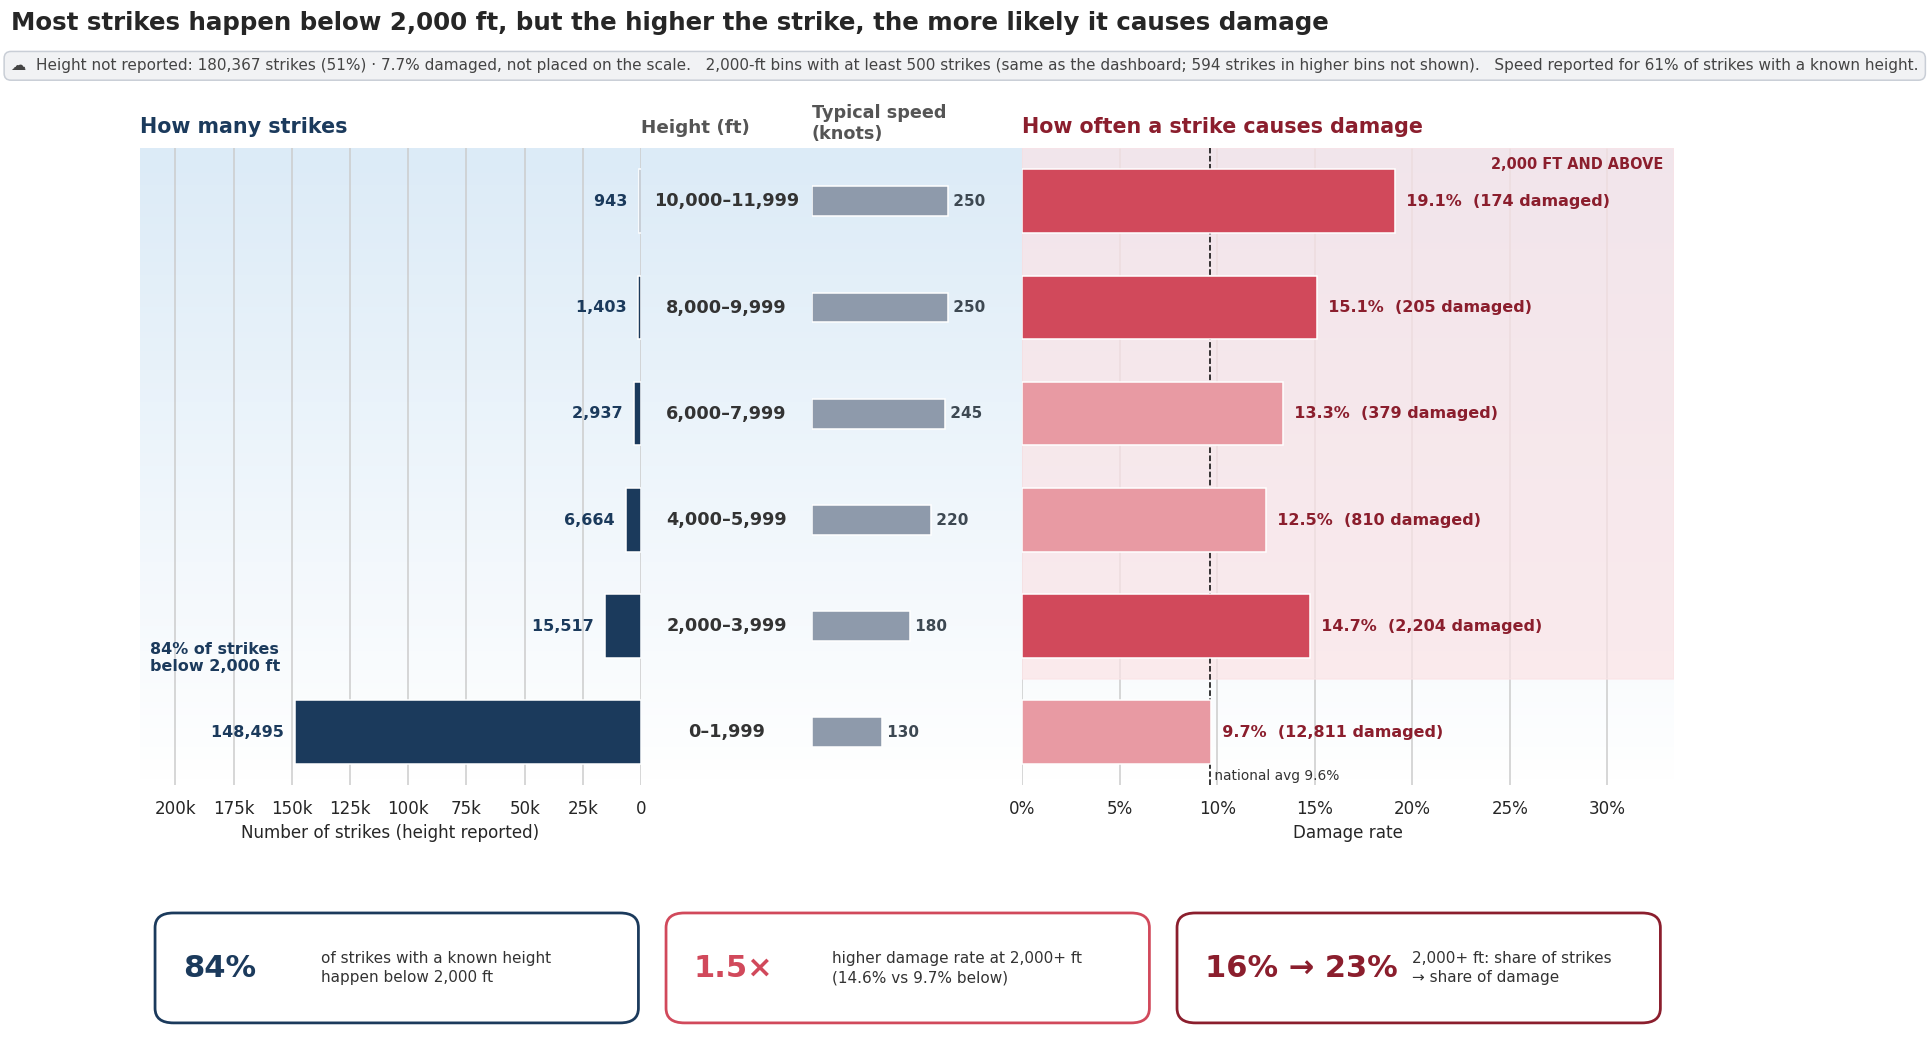

📌 84% of strikes with a reported height (in the bins shown) happened below 2,000 ft.
📌 Damage rate: 9.7% below 2,000 ft vs 14.6% at 2,000 ft and above (1.5x).
📌 2,000 ft and above: 16% of strikes but 23% of damaging strikes.
📌 Damage rate by bin: 0–1,999 ft 9.7%, 2,000–3,999 ft 14.7%, 4,000–5,999 ft 12.5%, 6,000–7,999 ft 13.3%, 8,000–9,999 ft 15.1%, 10,000–11,999 ft 19.1%
📌 Typical speed by bin (knots): 0–1,999 130, 2,000–3,999 180, 4,000–5,999 220, 6,000–7,999 245, 8,000–9,999 250, 10,000–11,999 250
📌 Height is missing for 51% of strikes; their damage rate is 7.7%.


In [22]:
# ---------- Section 5: altitude profile using the same 2,000-ft bins as the Tableau dashboard ----------
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

BIN_W, MIN_N = 2000, 500                                      # same bin width and minimum count as the dashboard
eda["HEIGHT_BIN"] = (np.floor(eda["HEIGHT"] / BIN_W) * BIN_W).astype("Int64")   # 0, 2000, 4000, ... (blank if no height)
g = eda.groupby("HEIGHT_BIN")
hb = pd.DataFrame({"strikes": g.size(), "damaged": g["DAMAGE_TARGET"].sum(), "rate": g["DAMAGE_TARGET"].mean(),
                   "speed": g["SPEED"].median(), "speed_n": g["SPEED"].count()}).sort_index()
alt = hb[hb["strikes"] >= MIN_N].copy()                       # ground level at the bottom, highest bin at the top
alt.index = [f"{int(b):,}–{int(b) + BIN_W - 1:,}" for b in alt.index]
nr_mask = eda["HEIGHT"].isna()
nr = pd.Series({"strikes": int(nr_mask.sum()), "rate": eda.loc[nr_mask, "DAMAGE_TARGET"].mean()})
yy = np.arange(len(alt)); n_rows = len(alt)
low_rows, high_rows = [0], list(range(1, n_rows))             # below 2,000 ft vs 2,000 ft and above
low_share = alt.iloc[0]["strikes"] / alt["strikes"].sum()
high_share_n = alt.iloc[1:]["strikes"].sum() / alt["strikes"].sum()
high_share_d = alt.iloc[1:]["damaged"].sum() / alt["damaged"].sum()
r_low = eda.loc[eda["HEIGHT"] < BIN_W, "DAMAGE_TARGET"].mean()
r_high = eda.loc[eda["HEIGHT"] >= BIN_W, "DAMAGE_TARGET"].mean()
speed_cov = eda.loc[eda["HEIGHT"].notna(), "SPEED"].notna().mean()
hidden = hb[hb["strikes"] < MIN_N]

fig = plt.figure(figsize=(18, 10.4))
gs = fig.add_gridspec(2, 4, width_ratios=[1, .34, .42, 1.3], height_ratios=[6, 1.15], wspace=0, hspace=.32)
axl, axm, axs, axr = [fig.add_subplot(gs[0, i]) for i in range(4)]
axk = fig.add_subplot(gs[1, :]); axk.axis("off")
sky = LinearSegmentedColormap.from_list("sky", ["#FFFFFF", "#DCEBF7"])
for ax in (axl, axm, axs, axr):                                # sky gets bluer with height
    ax.imshow(np.linspace(0, 1, 100).reshape(-1, 1), extent=(0, 1, -.5, n_rows - .5),
              transform=ax.get_yaxis_transform(), cmap=sky, aspect="auto", origin="lower", zorder=0)
    ax.set_ylim(-.5, n_rows - .5); ax.set_yticks([]); ax.grid(axis="y", visible=False)
    for sp in ax.spines.values(): sp.set_visible(False)
if high_rows:                                                  # light red band behind the "2,000 ft and above" rows
    axr.axhspan(min(high_rows) - .5, max(high_rows) + .5, color="#FBE3E6", alpha=.7, zorder=.6)

# LEFT: number of strikes (bars grow to the left)
smax = alt["strikes"].max()
axl.barh(yy, alt["strikes"], color=NAVY, height=.6, zorder=2)
for y_, n in zip(yy, alt["strikes"]):
    axl.text(n, y_, f"{n:,.0f}  ", ha="right", va="center", fontsize=10.5, fontweight="bold", color=NAVY, zorder=3)
axl.set_xlim(smax * 1.45, 0)
axl.xaxis.set_major_formatter(thousands)
axl.set_title("How many strikes", fontsize=13.5, color=NAVY, pad=10)
axl.set_xlabel("Number of strikes (height reported)")
axl.text(smax * 1.42, .55, f"{low_share:.0%} of strikes\nbelow {BIN_W:,} ft", ha="left", va="bottom", fontsize=10.5,
         fontweight="bold", color=NAVY, zorder=3)

# MIDDLE: height bins
axm.set_xlim(0, 1); axm.set_xticks([])
for y_, band in zip(yy, alt.index):
    axm.text(.5, y_, band, ha="center", va="center", fontsize=11.5, fontweight="bold", color="#333333", zorder=3)
axm.set_title("Height (ft)", fontsize=12, color="#555555", pad=10)

# SPEED column: typical (median) speed
vmax = alt["speed"].max() if alt["speed"].notna().any() else 1
axs.set_xlim(0, vmax * 1.55); axs.set_xticks([])
for y_, (v, n) in zip(yy, zip(alt["speed"], alt["speed_n"])):
    if pd.notna(v) and n >= 30:
        axs.barh(y_, v, color="#8E9AAB", height=.28, zorder=2)
        axs.text(v, y_, f" {v:.0f}", va="center", fontsize=10, color="#3D4852", fontweight="bold", zorder=3)
    else:
        axs.text(.05 * vmax, y_, "n/a", va="center", fontsize=9.5, color="gray", zorder=3)
axs.set_title("Typical speed\n(knots)", fontsize=11.5, color="#555555", pad=6)

# RIGHT: damage rate, with the number of damaging strikes
rcols = [RED if r > BASE_RATE * 1.5 else ("#E89AA3" if r > BASE_RATE else GREY) for r in alt["rate"]]
axr.barh(yy, alt["rate"], color=rcols, height=.6, zorder=2)
for y_, (r, d) in zip(yy, zip(alt["rate"], alt["damaged"])):
    axr.text(r, y_, f"  {r:.1%}  ({int(d):,} damaged)", va="center", fontsize=10.5, fontweight="bold",
             color="#8B1E2D", zorder=3)
axr.axvline(BASE_RATE, color="black", ls="--", lw=1, zorder=1)
axr.text(BASE_RATE, -.48, f" national avg {BASE_RATE:.1%}", fontsize=9, va="bottom", zorder=3, color="#333333")
axr.set_xlim(0, alt["rate"].max() * 1.75)
axr.xaxis.set_major_locator(mtick.MultipleLocator(.05))
axr.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axr.set_title("How often a strike causes damage", fontsize=13.5, color="#8B1E2D", pad=10)
axr.set_xlabel("Damage rate")
if high_rows:
    axr.text(alt["rate"].max() * 1.72, max(high_rows) + .42, f"{BIN_W:,} FT AND ABOVE", ha="right", va="top",
             fontsize=9.5, fontweight="bold", color="#8B1E2D", zorder=3)

# KEY-NUMBER CARDS
axk.set_xlim(0, 100); axk.set_ylim(0, 10)
cards = [(f"{low_share:.0%}", f"of strikes with a known height\nhappen below {BIN_W:,} ft", NAVY, 9),
         (f"{r_high / r_low:.1f}×", f"higher damage rate at {BIN_W:,}+ ft\n({r_high:.1%} vs {r_low:.1%} below)", RED, 9),
         (f"{high_share_n:.0%} → {high_share_d:.0%}", f"{BIN_W:,}+ ft: share of strikes\n→ share of damage", "#8B1E2D", 13.5)]
for i, (big, small, col, gap) in enumerate(cards):
    x0 = 1 + i * 33.3
    axk.add_patch(FancyBboxPatch((x0, .5), 31.5, 9, boxstyle="round,pad=0,rounding_size=1.2", fc="white", ec=col, lw=1.8))
    axk.text(x0 + 1.8, 5, big, fontsize=20, fontweight="bold", color=col, va="center")
    axk.text(x0 + 1.8 + gap, 5, small, fontsize=10, color="#333333", va="center", linespacing=1.4)

trend = "the higher the strike, the more likely it causes damage" if r_high > r_low else "damage rates stay similar with height"
fig.suptitle(f"Most strikes happen below {BIN_W:,} ft, but {trend}", fontsize=16, fontweight="bold", x=.06, ha="left", y=1.0)
fig.text(.06, .948, f"☁  Height not reported: {nr['strikes']:,.0f} strikes ({nr['strikes'] / len(eda):.0%}) · "
         f"{nr['rate']:.1%} damaged, not placed on the scale.   {BIN_W:,}-ft bins with at least {MIN_N} strikes "
         f"(same as the dashboard; {int(hidden['strikes'].sum()):,} strikes in higher bins not shown).   "
         f"Speed reported for {speed_cov:.0%} of strikes with a known height.", fontsize=10, color="#444444",
         bbox=dict(boxstyle="round,pad=.45", fc="#F1F2F4", ec="#C9CED6"))
save(fig, "05_height_bins"); plt.show()

finding(f"{low_share:.0%} of strikes with a reported height (in the bins shown) happened below {BIN_W:,} ft.")
finding(f"Damage rate: {r_low:.1%} below {BIN_W:,} ft vs {r_high:.1%} at {BIN_W:,} ft and above ({r_high / r_low:.1f}x).")
finding(f"{BIN_W:,} ft and above: {high_share_n:.0%} of strikes but {high_share_d:.0%} of damaging strikes.")
finding("Damage rate by bin: " + ", ".join(f"{b} ft {r:.1%}" for b, r in alt["rate"].items()))
finding("Typical speed by bin (knots): " + ", ".join(f"{b} {v:.0f}" for b, v in alt["speed"].dropna().items()))
finding(f"Height is missing for {nr['strikes'] / len(eda):.0%} of strikes; their damage rate is {nr['rate']:.1%}.")

**Insight:** **71%** of strikes with a known height happen at or below 500 ft, mostly on the ground. But **altitude raises the stakes**: above 1,000 ft, **15.1%** of strikes cause damage, **1.8×** the rate at or below 500 ft (8.4%). Strikes above 1,000 ft are only **22%** of strikes but about **33%** of damaging strikes. Typical speed rises from about 120 knots on the ground to 250 knots above 5,000 ft, so each hit carries more energy. Height is missing for 51% of strikes (damage rate 7.7%).

**EDA decision:**
- Keep `HEIGHT` as **height bands** (or log-transformed), since raw values are very skewed.
- Keep the `HEIGHT_MISSING` indicator, because missing height is not random (Section 9).
- Height and speed rise together, so we will **check for overlap** between height, speed and phase before modeling.

*Note for the dashboard:* use the same height bands as this chart (Ground, 1–100, 101–500, 501–1,000, 1,001–3,000, 3,001–5,000, 5,000+ ft) so the numbers match exactly.

## 6. Does the animal's size, or the number of animals, matter?
*Why it matters:* physics suggests heavier animals and flocks should cause more damage. This chart checks how strong that effect is.

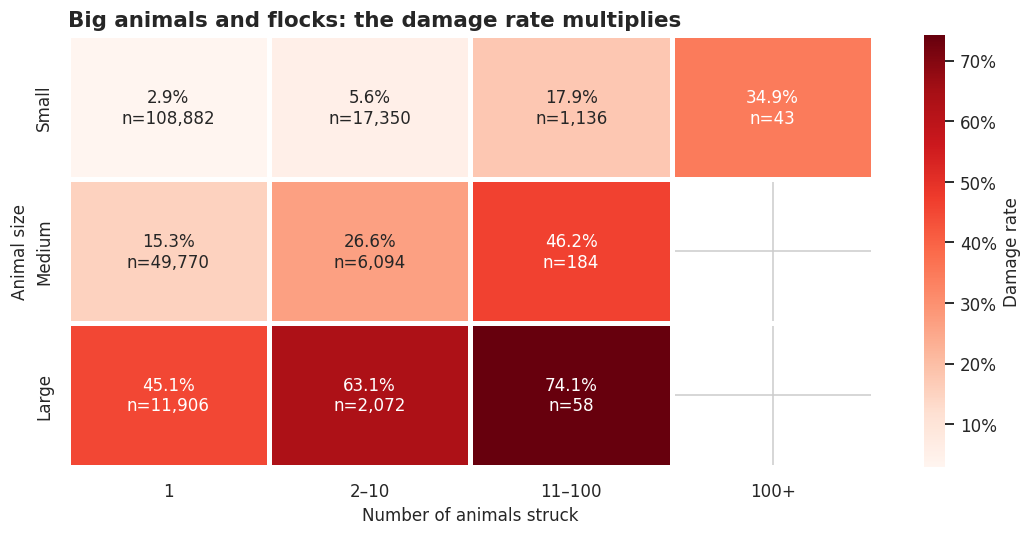

📌 Single small animal: 2.9% damage rate. Any large animal: 47.8% (≈17x higher).
📌 Highest cell: ('Large', '11–100') at 74.1%.


In [14]:
size_order = [s for s in ["Small", "Medium", "Large"] if s in eda["SIZE_C"].unique()]
struck_order = [s for s in ["1", "2–10", "11–100", "100+"] if s in eda["STRUCK_BIN"].unique()]
sub = eda[eda["SIZE_C"].isin(size_order) & eda["STRUCK_BIN"].isin(struck_order)]
rate = sub.pivot_table(index="SIZE_C", columns="STRUCK_BIN", values="DAMAGE_TARGET", aggfunc="mean").reindex(index=size_order, columns=struck_order)
n = sub.pivot_table(index="SIZE_C", columns="STRUCK_BIN", values="DAMAGE_TARGET", aggfunc="count").reindex(index=size_order, columns=struck_order)
labels = rate.map(lambda v: f"{v:.1%}" if pd.notna(v) else "") + "\n" + n.map(lambda v: f"n={v:,.0f}" if pd.notna(v) else "")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(rate.where(n >= 30), annot=labels.where(n >= 30, "too few"), fmt="", cmap="Reds", ax=ax,
            cbar_kws={"label": "Damage rate", "format": mtick.PercentFormatter(xmax=1, decimals=0)},
            linewidths=2, linecolor="white", annot_kws={"fontsize": 11})
ax.set_xlabel("Number of animals struck"); ax.set_ylabel("Animal size")
ax.set_title("Big animals and flocks: the damage rate multiplies")
fig.tight_layout(); save(fig, "06_size_vs_number_struck"); plt.show()

r_small1 = rate.loc["Small", "1"] if "Small" in rate.index else np.nan
r_large = sub.loc[sub["SIZE_C"] == "Large", "DAMAGE_TARGET"].mean()
finding(f"Single small animal: {r_small1:.1%} damage rate. Any large animal: {r_large:.1%} "
        f"(≈{r_large/r_small1:.0f}x higher).")
finding(f"Highest cell: {rate.stack().idxmax()} at {rate.stack().max():.1%}.")

**Insight:** Animal size is the single clearest driver of damage: a single **small** animal causes damage only **2.9%** of the time, while any **large** animal does so **48%** of the time (about 17× higher). The number of animals struck **multiplies** the effect: for large animals, damage rises from **45%** (one animal) to **63%** (2–10) and **74%** (11–100). The worst cases combine both.

**EDA decision:**
- `SIZE` and `NUM_STRUCK` will be **core features** of the model.
- Their combined effect suggests trying an **interaction feature** (size × number struck), or a tree-based model that captures interactions automatically.
- Cells with fewer than 30 assessed strikes are hidden to avoid misleading rates.

## 7. Which species are the most dangerous?
*Why it matters:* wildlife managers have limited resources. A **risk matrix** separates species that are merely common from species that are actually dangerous.

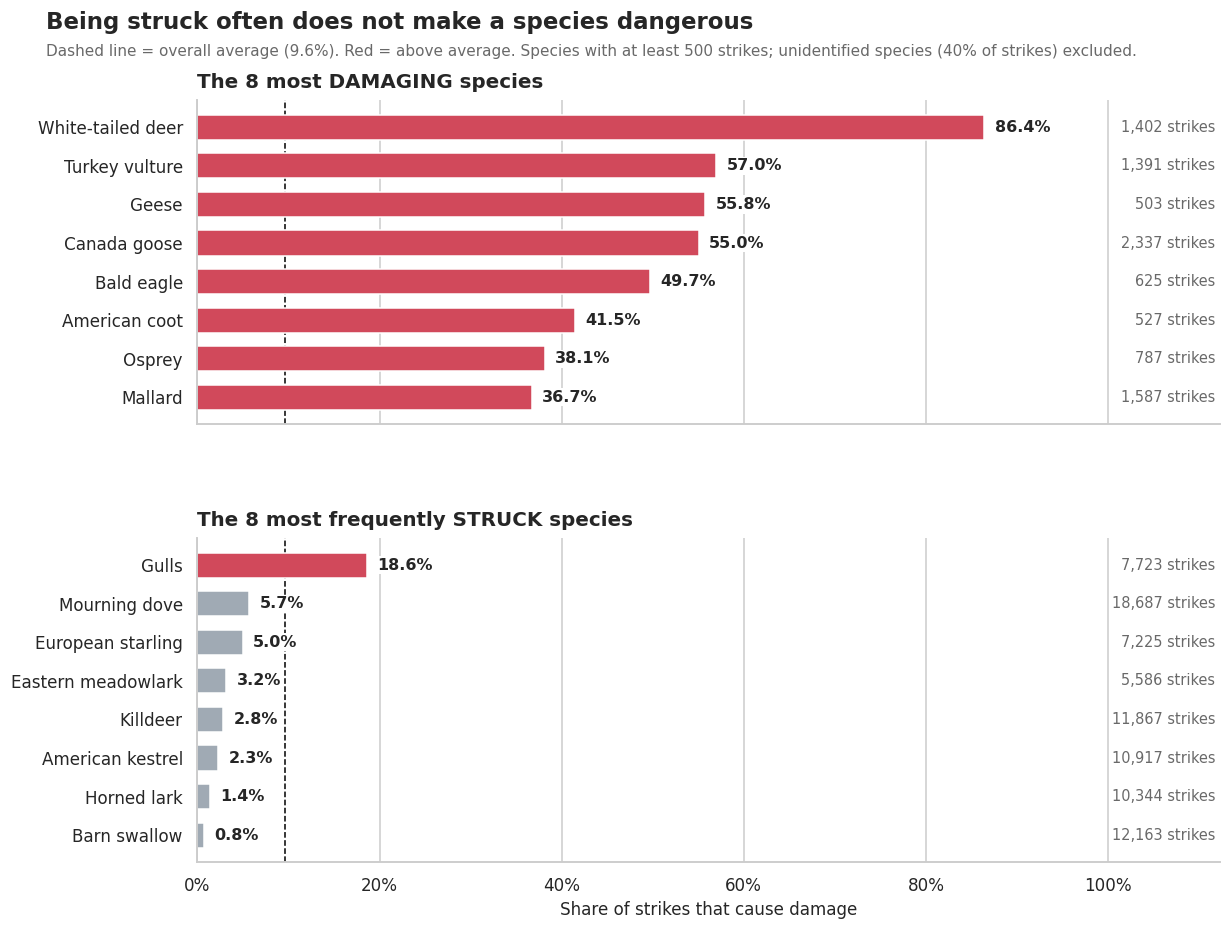

📌 Most damaging: White-tailed deer (86%), Turkey vulture (57%), Geese (56%)
📌 Most frequently struck: Mourning dove (18,687 strikes, 5.7% damage rate), Barn swallow (12,163 strikes, 0.8% damage rate), Killdeer (11,867 strikes, 2.8% damage rate)


In [15]:
# ---------- Option B: two ranked bar charts on the same damage-rate scale ----------
known_sp = eda[eda["SPECIES_KNOWN"]]
sp = known_sp.groupby("SPECIES").agg(strikes=("DAMAGE_TARGET", "size"), rate=("DAMAGE_TARGET", "mean"))
sp = sp[sp["strikes"] >= 500]                                    # only species with stable rates
dangerous = sp.nlargest(8, "rate").sort_values("rate")
common = sp.nlargest(8, "strikes").sort_values("rate")
x_max = dangerous["rate"].max() * 1.3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, gridspec_kw={"hspace": .35})
for ax, data, title in [
        (ax1, dangerous, "The 8 most DAMAGING species"),
        (ax2, common, "The 8 most frequently STRUCK species")]:
    y = np.arange(len(data))
    ax.barh(y, data["rate"], color=[RED if r > BASE_RATE else GREY for r in data["rate"]], height=.65)
    for yi, (n, r) in zip(y, data.iterrows()):
        ax.text(r["rate"] + x_max * .01, yi, f"{r['rate']:.1%}", va="center", fontsize=10.5, fontweight="bold",
                bbox=dict(fc="white", ec="none", pad=1), zorder=3)
        ax.text(x_max * .995, yi, f"{int(r['strikes']):,} strikes", va="center", ha="right", fontsize=9.5, color="dimgray")
    ax.set_yticks(y); ax.set_yticklabels(data.index, fontsize=11)
    ax.axvline(BASE_RATE, color="black", ls="--", lw=1, zorder=0)
    ax.set_title(title, fontsize=13, pad=8)
    ax.grid(axis="y", visible=False)
ax2.set_xlim(0, x_max)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.set_xlabel("Share of strikes that cause damage")
fig.suptitle("Being struck often does not make a species dangerous", fontsize=15, fontweight="bold",
             x=.01, ha="left", y=.97)
fig.text(.01, .925, f"Dashed line = overall average ({BASE_RATE:.1%}). Red = above average. Species with at least 500 strikes; unidentified species ({1 - eda['SPECIES_KNOWN'].mean():.0%} of strikes) excluded.",
         fontsize=10, color="dimgray")
save(fig, "07_species_bars"); plt.show()

finding("Most damaging: " + ", ".join(f"{s} ({r:.0%})" for s, r in dangerous["rate"].nlargest(3).items()))
finding("Most frequently struck: " + ", ".join(f"{s} ({int(n):,} strikes, {common.loc[s, 'rate']:.1%} damage rate)"
                                           for s, n in common["strikes"].nlargest(3).items()))

**Insight:** The most frequently struck species are almost harmless: **mourning doves** (18,687 strikes) cause damage only **5.7%** of the time, and **barn swallows** just **0.8%**. **Large animals** are the real threat: a **white-tailed deer** strike causes damage **86%** of the time, followed by **turkey vultures (57%)**, **geese (56%)** and **Canada geese (55%)**, all far above the 9.6% average. **Gulls** are the one common species with an above-average rate (19%). Species is unidentified for **40%** of strikes.

**EDA decision:**
- `SPECIES` has hundreds of levels, so we will group it into **risk tiers** (or use target encoding fitted on the training set only), with an "Unidentified" tier.
- Wildlife managers should prioritize **large, high-risk species** over the most common ones. This ranking is also a view in the dashboard.

## 8. Which aircraft parts get hit, and which get damaged?
*Why it matters:* this shows **how** strikes cause damage. Note: these columns are recorded *after* the strike, so they are used **for understanding only** and are excluded from the model (leakage).

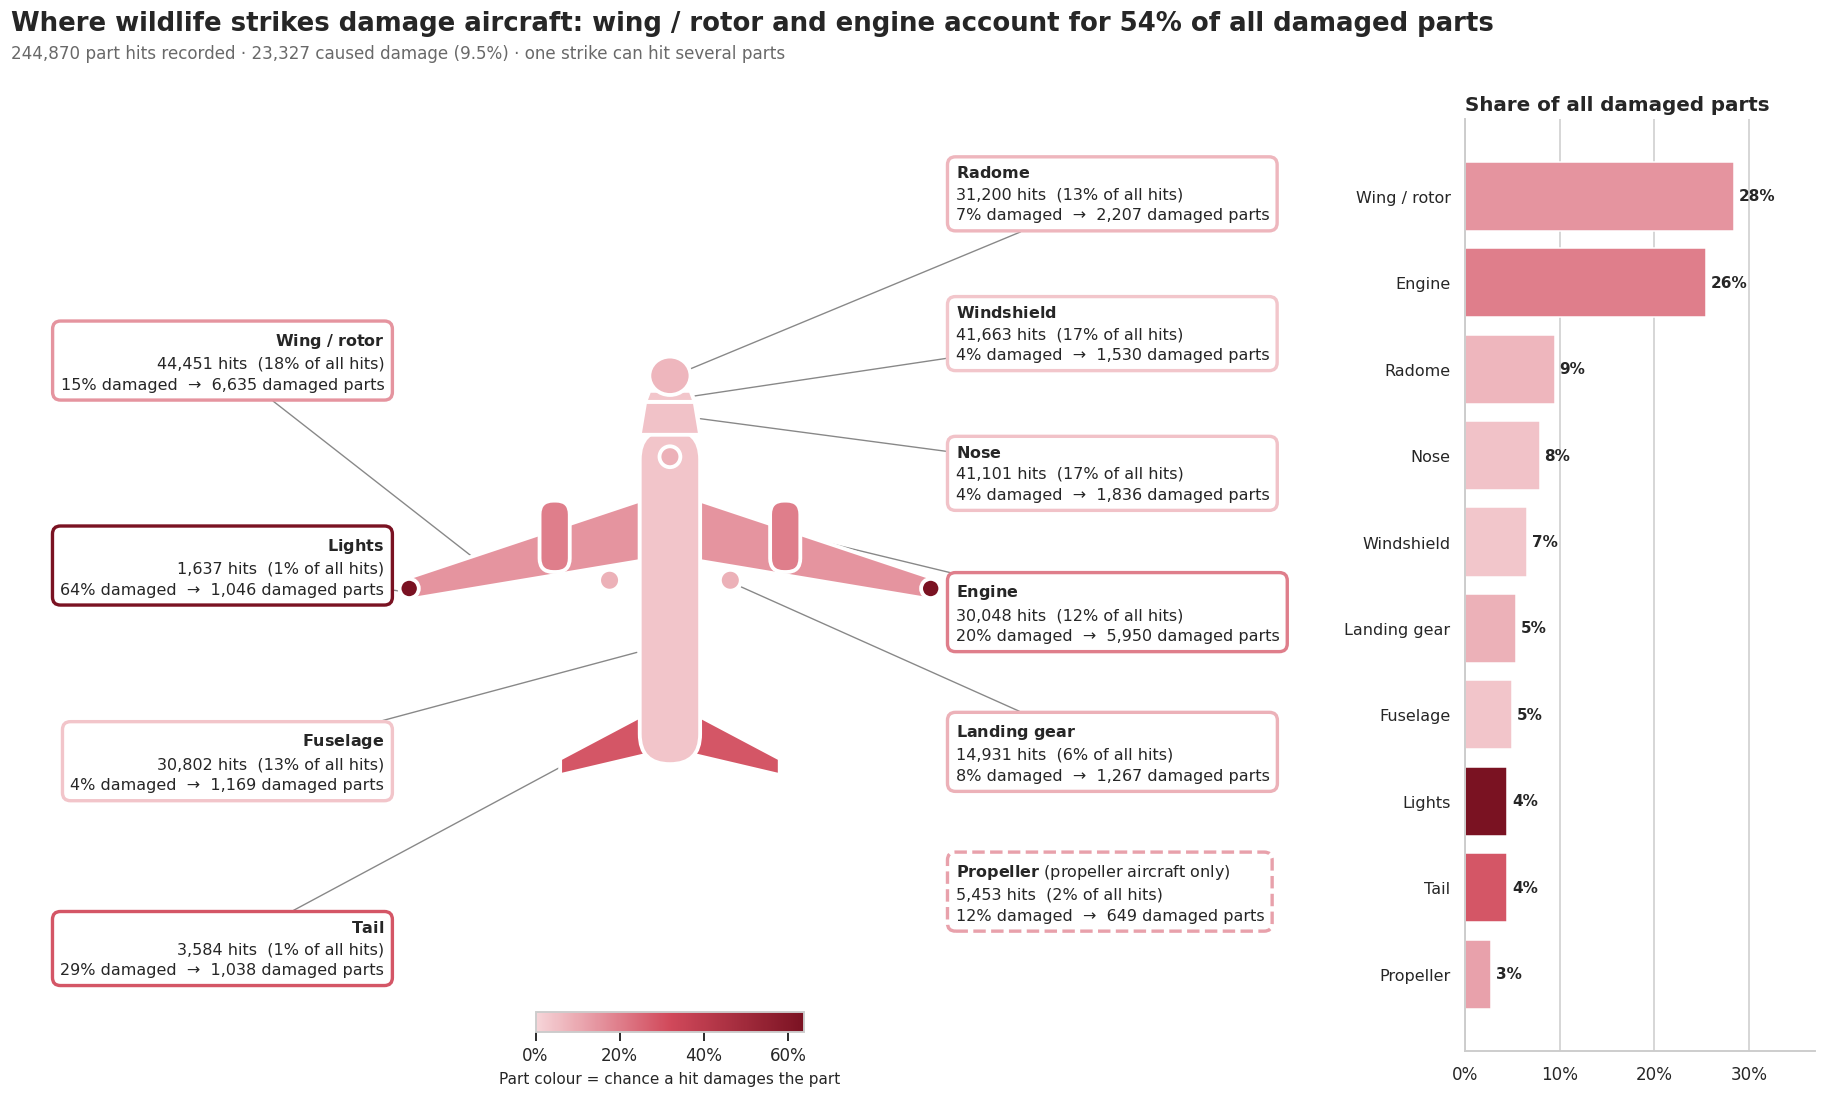

📌 Most damaged parts: Wing / rotor (28% of all damage), Engine (26% of all damage), Radome (9% of all damage)
📌 Most-hit part: Wing / rotor (18% of all hits)
📌 Most fragile per hit: Lights (64%), Tail (29%), Engine (20%)


In [16]:
parts = {"Windshield": "WINDSHLD", "Nose": "NOSE", "Radome": "RAD", "Engine": "ENG", "Propeller": "PROP",
         "Wing / rotor": "WING_ROT", "Fuselage": "FUSE", "Landing gear": "LG", "Tail": "TAIL", "Lights": "LGHTS"}
rows = []
for label, code_ in parts.items():
    if code_ == "ENG":   # combine the four engine columns: struck/damaged if any engine was
        s_cols = [c for c in eda if c.startswith("STR_ENG")]; d_cols = [c for c in eda if c.startswith("DAM_ENG")]
        if not s_cols: continue
        struck = eda[s_cols].astype(float).max(axis=1) > 0
        damaged = eda[d_cols].astype(float).max(axis=1) > 0
    else:
        if f"STR_{code_}" not in eda: continue
        struck = eda[f"STR_{code_}"].astype(float) > 0
        damaged = eda[f"DAM_{code_}"].astype(float) > 0
    rows.append((label, int(struck.sum()), int((struck & damaged).sum())))
comp = pd.DataFrame(rows, columns=["part", "hits", "damaged"]).set_index("part")
comp["pct"] = comp["damaged"] / comp["hits"].clip(lower=1)

# ---------- Section 8: aircraft damage map ----------
from matplotlib.patches import Polygon, Ellipse, Circle, FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap, Normalize

comp["share_hits"] = comp["hits"] / comp["hits"].sum()
comp["share_dmg"] = comp["damaged"] / comp["damaged"].sum()
cmap = LinearSegmentedColormap.from_list("risk", ["#F6D5D9", RED, "#7A1222"])
norm = Normalize(vmin=0, vmax=comp["pct"].max())
col = lambda p: cmap(norm(comp.loc[p, "pct"]))

fig = plt.figure(figsize=(20, 11))
gs = fig.add_gridspec(1, 2, width_ratios=[3.2, 1], wspace=.32)
ax = fig.add_subplot(gs[0]); axb = fig.add_subplot(gs[1])
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
air = ax.inset_axes([.25, .07, .50, .9])          # the aircraft lives here

# ---- aircraft outline (top view, nose up); each part colored by its damage rate ----
ec = dict(edgecolor="white", linewidth=2.5)
for s in (-1, 1):
    air.add_patch(Polygon([(s*1.1, 1.0), (s*9.5, -1.8), (s*9.5, -2.6), (s*1.1, -1.2)], facecolor=col("Wing / rotor"), **ec))
air.add_patch(Polygon([(-0.6, -6.6), (-4, -8.4), (-4, -9), (-0.6, -8.2), (0.6, -8.2), (4, -9), (4, -8.4), (0.6, -6.6)],
                     facecolor=col("Tail"), **ec))
air.add_patch(FancyBboxPatch((-1.1, -8.6), 2.2, 12.2, boxstyle="round,pad=0,rounding_size=1.1", facecolor=col("Fuselage"), **ec))
air.add_patch(Polygon([(-1.1, 3.4), (1.1, 3.4), (0.9, 4.6), (-0.9, 4.6)], facecolor=col("Nose"), **ec))
air.add_patch(Polygon([(-0.9, 4.6), (0.9, 4.6), (0.75, 5.0), (-0.75, 5.0)], facecolor=col("Windshield"), **ec))
air.add_patch(Ellipse((0, 5.55), 1.5, 1.4, facecolor=col("Radome"), **ec))
for xe in (-4.2, 4.2):
    air.add_patch(FancyBboxPatch((xe - .55, -1.6), 1.1, 2.6, boxstyle="round,pad=0,rounding_size=.5", facecolor=col("Engine"), **ec))
for xg, yg in [(-2.2, -1.9), (2.2, -1.9), (0, 2.6)]:
    air.add_patch(Circle((xg, yg), .38, facecolor=col("Landing gear"), **ec))
for xl in (-9.5, 9.5):
    air.add_patch(Circle((xl, -2.2), .35, facecolor=col("Lights"), **ec))

# ---- information cards: hits, share of all hits, damage rate, damaged count ----
def card(part, anchor, pos, ha):
    r = comp.loc[part]
    txt = (f"$\\bf{{{part.replace(' ', '~')}}}$\n"
           f"{int(r['hits']):,} hits  ({r['share_hits']:.0%} of all hits)\n"
           f"{r['pct']:.0%} damaged  →  {int(r['damaged']):,} damaged parts")
    ax.annotate(txt, anchor, pos, xycoords=air.transData, textcoords=ax.transAxes, ha=ha, va="center", fontsize=10.5, linespacing=1.5,
                bbox=dict(boxstyle="round,pad=.5", fc="white", ec=col(part), lw=2.2),
                arrowprops=dict(arrowstyle="-", color="#888888", lw=.9, shrinkA=0, shrinkB=2))

L, R = .245, .755          # card positions in axes fractions (left / right columns)
card("Radome",       (0.5, 5.7),   (R, .92), "left")
card("Windshield",   (0.8, 4.8),   (R, .77), "left")
card("Nose",         (1.0, 4.0),   (R, .62), "left")
card("Engine",       (4.75, -0.3), (R, .47), "left")
card("Landing gear", (2.5, -2.1),  (R, .32), "left")
card("Wing / rotor", (-7.0, -1.2), (L, .74), "right")
card("Lights",       (-9.8, -2.3), (L, .52), "right")
card("Fuselage",     (-1.1, -4.5), (L, .31), "right")
card("Tail",         (-3.6, -8.5), (L, .11), "right")
if "Propeller" in comp.index:      # not drawn: jets have no propeller
    r = comp.loc["Propeller"]
    ax.text(R, .17, f"$\\bf{{Propeller}}$ (propeller aircraft only)\n{int(r['hits']):,} hits  ({r['share_hits']:.0%} of all hits)\n"
            f"{r['pct']:.0%} damaged  →  {int(r['damaged']):,} damaged parts", transform=ax.transAxes, ha="left", va="center",
            fontsize=10.5, linespacing=1.5, bbox=dict(boxstyle="round,pad=.5", fc="white", ec=col("Propeller"), lw=2.2, ls="--"))
air.set_xlim(-10.2, 10.2); air.set_ylim(-9.4, 6.6); air.set_aspect("equal"); air.axis("off")

# colour legend under the aircraft
cax = ax.inset_axes([.38, .02, .24, .022])
cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cax, orientation="horizontal",
                  format=mtick.PercentFormatter(xmax=1, decimals=0))
cb.set_label("Part colour = chance a hit damages the part", fontsize=10)

# ---- side panel: where the damage actually happens ----
sd = comp.sort_values("share_dmg")
axb.barh(sd.index, sd["share_dmg"], color=[col(p) for p in sd.index], edgecolor="white")
for i, (p, r) in enumerate(sd.iterrows()):
    axb.text(r["share_dmg"] + .005, i, f"{r['share_dmg']:.0%}", va="center", fontsize=10, fontweight="bold")
axb.set_xlim(0, sd["share_dmg"].max() * 1.3)
axb.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axb.set_title("Share of all damaged parts", fontsize=13, loc="left")
axb.grid(axis="y", visible=False); axb.tick_params(axis="y", labelsize=10.5)

# ---- headline + summary ----
top2 = comp["damaged"].nlargest(2)
fig.suptitle(f"Where wildlife strikes damage aircraft: {top2.index[0].lower()} and {top2.index[1].lower()} "
             f"account for {top2.sum() / comp['damaged'].sum():.0%} of all damaged parts",
             fontsize=17, fontweight="bold", x=.08, ha="left", y=.97)
fig.text(.08, .93, f"{comp['hits'].sum():,} part hits recorded · {comp['damaged'].sum():,} caused damage "
         f"({comp['damaged'].sum() / comp['hits'].sum():.1%}) · one strike can hit several parts",
         fontsize=11, color="dimgray")
save(fig, "08_components"); plt.show()

finding("Most damaged parts: " + ", ".join(f"{p} ({r:.0%} of all damage)" for p, r in comp["share_dmg"].nlargest(3).items()))
finding("Most-hit part: " + f"{comp['hits'].idxmax()} ({comp['share_hits'].max():.0%} of all hits)")
finding("Most fragile per hit: " + ", ".join(f"{p} ({r:.0%})" for p, r in comp["pct"].nlargest(3).items()))

**Insight:** Being hit often doesn't mean being damaged often. The **windshield and nose** are each hit about 41,000 times but damaged only **4%** of the time. The **wings/rotors** (15% damaged) and **engines** (20% damaged) together account for **over half of all damaged parts**, and engine damage is the most safety-critical because it can cause loss of thrust. The **tail (29%)** and **lights (64%)** break easily but are rarely hit.

**EDA decision:**
- All `STR_*`, `DAM_*` and `ING_*` columns are **excluded from model features**, since they describe the outcome of the strike, not the conditions before it (leakage).
- They will be used in the **dashboard** for a damage-by-part breakdown.

## 9. Is missing data random?
*Why it matters:* reporting is voluntary. If damaging strikes are reported in more detail, then **missingness itself carries information** and must be handled carefully.

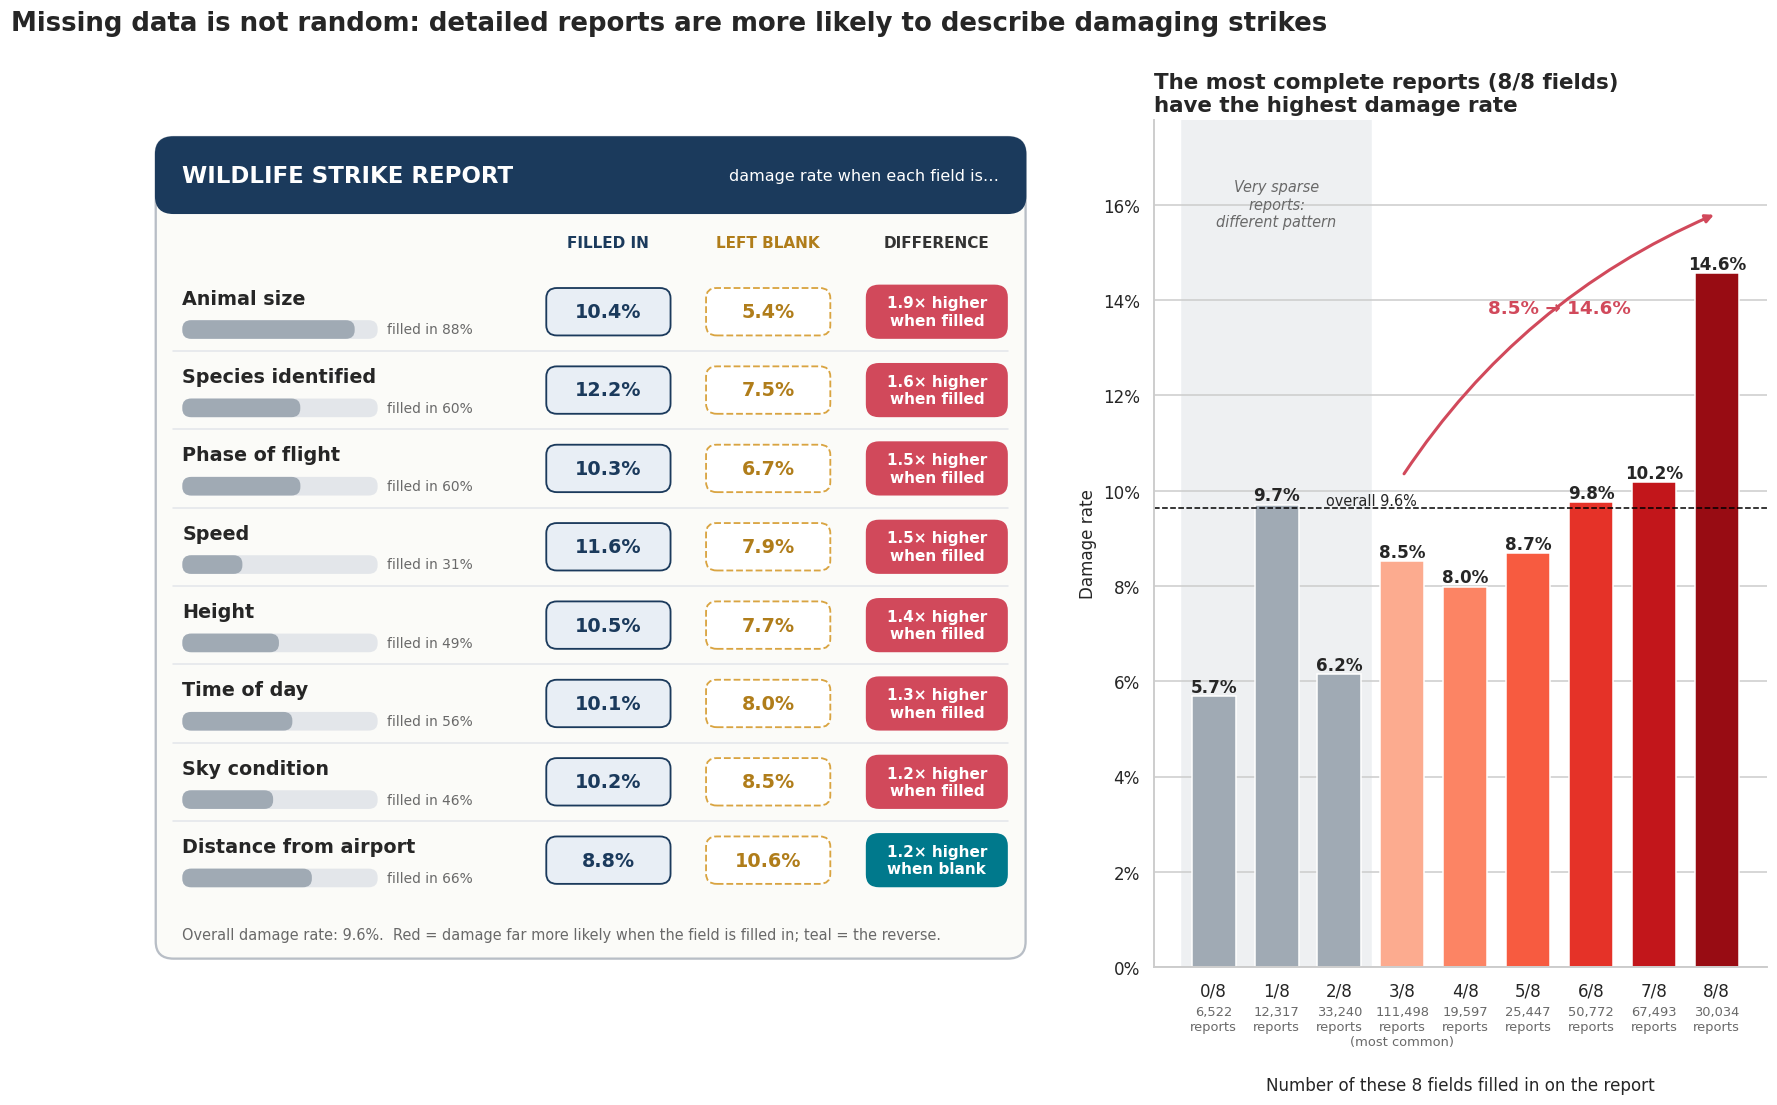

📌 Biggest gap: Animal size. Damage rate 10.4% when filled in vs 5.4% when blank (1.9x).
📌 From the most common report (3/8 fields, 111,498 reports) to fully complete reports: damage rate 8.5% → 14.6%.
📌 Median report year by number of fields filled: 0/8 → 2023, 1/8 → 2006, 2/8 → 2020, 3/8 → 2017, 4/8 → 2016, 5/8 → 2017, 6/8 → 2013, 7/8 → 2014, 8/8 → 2013
📌 0/8 fields - most common report sources: FAA Form 5200-7-E (88%), Air Transport Report (5%)
📌 1/8 fields - most common report sources: Air Transport Report (45%), FAA Form 5200-7-E (37%)
📌 2/8 fields - most common report sources: FAA Form 5200-7-E (68%), MOR (15%)
📌 3/8 fields - most common report sources: FAA Form 5200-7-E (81%), MOR (5%)
📌 4/8 fields - most common report sources: FAA Form 5200-7-E (37%), MOR (23%)
📌 5/8 fields - most common report sources: FAA Form 5200-7-E (53%), Multiple (16%)
📌 6/8 fields - most common report sources: FAA Form 5200-7-E (53%), FAA Form 5200-7 (24%)
📌 7/8 fields - most common report sources: FAA F

In [17]:
# ---------- Section 9: does a more detailed report mean a more damaging strike? ----------
from matplotlib.patches import FancyBboxPatch

fields = {                                   # field name on the report form -> "was it filled in?"
    "Speed": eda["SPEED"].notna(),
    "Height": eda["HEIGHT"].notna(),
    "Phase of flight": ~is_unknown(eda["PHASE"]),
    "Time of day": ~is_unknown(eda["TIME_OF_DAY"]),
    "Sky condition": ~is_unknown(eda["SKY"]),
    "Animal size": ~is_unknown(eda["SIZE_C"]),
    "Distance from airport": eda["DISTANCE"].notna(),
    "Species identified": eda["SPECIES_KNOWN"].astype(bool),
}
rows = []
for name, filled in fields.items():
    r_f, r_b = eda.loc[filled, "DAMAGE_TARGET"].mean(), eda.loc[~filled, "DAMAGE_TARGET"].mean()
    rows.append((name, filled.mean(), r_f, r_b, r_f / max(r_b, 1e-9)))
miss = pd.DataFrame(rows, columns=["field", "share_filled", "rate_filled", "rate_blank", "ratio"]).set_index("field")
miss = miss.sort_values("ratio", ascending=False)

# report completeness: how many of these 8 fields were filled in per strike
filled_count = pd.concat(fields, axis=1).sum(axis=1)
comp_tab = eda.groupby(filled_count)["DAMAGE_TARGET"].agg(reports="size", rate="mean")
comp_tab = comp_tab[comp_tab["reports"] >= 200]             # skip tiny groups

fig = plt.figure(figsize=(19, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1], wspace=.16)
axf = fig.add_subplot(gs[0]); axc = fig.add_subplot(gs[1])

# ---- LEFT: a strike report form, one row per field ----
axf.set_xlim(0, 100); axf.set_ylim(0, 100); axf.axis("off")
axf.add_patch(FancyBboxPatch((1, 1), 98, 97, boxstyle="round,pad=0,rounding_size=2", fc="#FBFBF8", ec="#B8BEC6", lw=1.5))
axf.add_patch(FancyBboxPatch((1, 89), 98, 9, boxstyle="round,pad=0,rounding_size=2", fc=NAVY, ec=NAVY))
axf.text(4, 93.5, "WILDLIFE STRIKE REPORT", color="white", fontsize=15, fontweight="bold", va="center")
axf.text(96, 93.5, "damage rate when each field is…", color="white", fontsize=10.5, va="center", ha="right")
axf.text(52, 85, "FILLED IN", ha="center", fontsize=10, fontweight="bold", color=NAVY)
axf.text(70, 85, "LEFT BLANK", ha="center", fontsize=10, fontweight="bold", color="#B07D1A")
axf.text(89, 85, "DIFFERENCE", ha="center", fontsize=10, fontweight="bold", color="#333333")

row_h = 74 / len(miss)
for i, (name, r) in enumerate(miss.iterrows()):
    yc = 82 - row_h * (i + .5)
    if i: axf.plot([3, 97], [yc + row_h / 2] * 2, color="#E3E6EA", lw=1)
    # field label + "how often filled" bar
    axf.text(4, yc + 1.6, name, fontsize=12.5, fontweight="bold", va="center")
    axf.add_patch(FancyBboxPatch((4, yc - 3.2), 22, 2.2, boxstyle="round,pad=0,rounding_size=1", fc="#E3E6EA", ec="none"))
    axf.add_patch(FancyBboxPatch((4, yc - 3.2), 22 * r["share_filled"], 2.2, boxstyle="round,pad=0,rounding_size=1",
                                 fc=GREY, ec="none"))
    axf.text(27, yc - 2.1, f"filled in {r['share_filled']:.0%}", fontsize=9, va="center", color="dimgray")
    # damage rate when filled / blank
    axf.add_patch(FancyBboxPatch((45, yc - 2.8), 14, 5.6, boxstyle="round,pad=0,rounding_size=1.2", fc="#E8EEF5", ec=NAVY, lw=1.2))
    axf.text(52, yc, f"{r['rate_filled']:.1%}", ha="center", va="center", fontsize=12.5, fontweight="bold", color=NAVY)
    axf.add_patch(FancyBboxPatch((63, yc - 2.8), 14, 5.6, boxstyle="round,pad=0,rounding_size=1.2", fc="white",
                                 ec="#D9A441", lw=1.2, ls="--"))
    axf.text(70, yc, f"{r['rate_blank']:.1%}", ha="center", va="center", fontsize=12.5, fontweight="bold", color="#B07D1A")
    # difference badge
    ratio = r["ratio"]
    if ratio >= 1.15:   txt, colr = f"{ratio:.1f}× higher\nwhen filled", RED
    elif ratio <= 1/1.15: txt, colr = f"{1/ratio:.1f}× higher\nwhen blank", TEAL
    else:               txt, colr = "about the\nsame", GREY
    axf.add_patch(FancyBboxPatch((81, yc - 3.2), 16, 6.4, boxstyle="round,pad=0,rounding_size=1.5", fc=colr, ec="none"))
    axf.text(89, yc, txt, ha="center", va="center", fontsize=10, fontweight="bold", color="white", linespacing=1.2)
axf.text(4, 3.3, f"Overall damage rate: {BASE_RATE:.1%}.  Red = damage far more likely when the field is filled in; "
         "teal = the reverse.", fontsize=9.5, color="dimgray")

# ---- RIGHT: report completeness vs damage rate ----
k0 = int(comp_tab["reports"].idxmax())                     # the most common report (the "standard" short form)
trend = comp_tab.loc[k0:]
reds = plt.cm.Reds(np.linspace(.3, .9, len(trend)))
colors = [GREY if k < k0 else reds[list(trend.index).index(k)] for k in comp_tab.index]
axc.bar(comp_tab.index, comp_tab["rate"], color=colors, width=.7, edgecolor="white")
ymax = comp_tab["rate"].max() * 1.22
for x, r in comp_tab.iterrows():
    axc.text(x, r["rate"], f"{r['rate']:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    axc.text(x, -ymax * .045, f"{int(r['reports']):,}\nreports" + ("\n(most common)" if x == k0 else ""), ha="center", va="top", fontsize=8.5, color="dimgray")
if k0 > comp_tab.index.min():                               # shade the very sparse reports
    axc.axvspan(comp_tab.index.min() - .5, k0 - .5, color="#EEF0F2", zorder=0)
    axc.text((comp_tab.index.min() + k0 - 1) / 2, ymax * .93, "Very sparse\nreports:\ndifferent pattern",
             ha="center", va="top", fontsize=9.5, color="dimgray", style="italic")
axc.annotate("", xy=(trend.index[-1], trend["rate"].iloc[-1] + ymax * .07),
             xytext=(k0, trend["rate"].iloc[0] + ymax * .1),
             arrowprops=dict(arrowstyle="-|>", color=RED, lw=2, connectionstyle="arc3,rad=-.15"))
axc.text((k0 + trend.index[-1]) / 2, trend["rate"].max() * .82 + ymax * .1,
         f"{trend['rate'].iloc[0]:.1%} → {trend['rate'].iloc[-1]:.1%}", color=RED, fontsize=12, fontweight="bold",
         ha="center")
axc.axhline(BASE_RATE, color="black", ls="--", lw=1)
axc.text(k0 - .5, BASE_RATE, f"overall {BASE_RATE:.1%}", va="bottom", ha="center", fontsize=9.5)
axc.set_xticks(comp_tab.index)
axc.set_xticklabels([f"{int(k)}/{len(fields)}" for k in comp_tab.index], fontsize=11)
axc.set_ylim(0, ymax)
axc.yaxis.set_major_locator(mtick.MultipleLocator(.02))
axc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axc.set_xlabel("Number of these 8 fields filled in on the report", fontsize=11, labelpad=50)
axc.set_ylabel("Damage rate")
axc.grid(axis="x", visible=False)
axc.set_title(f"The most complete reports ({len(fields)}/{len(fields)} fields)\nhave the highest damage rate",
              fontsize=14, loc="left")

fig.suptitle("Missing data is not random: detailed reports are more likely to describe damaging strikes",
             fontsize=17, fontweight="bold", x=.06, ha="left", y=.98)
save(fig, "09_missingness_vs_damage"); plt.show()

top = miss["ratio"].idxmax()
finding(f"Biggest gap: {top}. Damage rate {miss.loc[top, 'rate_filled']:.1%} when filled in vs "
        f"{miss.loc[top, 'rate_blank']:.1%} when blank ({miss.loc[top, 'ratio']:.1f}x).")
finding(f"From the most common report ({k0}/{len(fields)} fields, {int(comp_tab.loc[k0, 'reports']):,} reports) to "
        f"fully complete reports: damage rate {trend['rate'].iloc[0]:.1%} → {trend['rate'].iloc[-1]:.1%}.")
if "YEAR" in eda:   # clue for the sparse reports: are they mostly older records?
    yr = eda.groupby(filled_count)["YEAR"].median()
    finding("Median report year by number of fields filled: " + ", ".join(f"{int(k)}/8 → {int(v)}" for k, v in yr.items()))
if "SOURCE" in eda:  # clue: who filed the report (e.g. airport staff finding remains vs. pilots / airlines)
    for k in comp_tab.index:
        top_src = eda.loc[filled_count == k, "SOURCE"].value_counts(normalize=True).head(2)
        finding(f"{int(k)}/8 fields - most common report sources: " + ", ".join(f"{s_} ({p:.0%})" for s_, p in top_src.items()))
rev = miss[miss["ratio"] < 1 / 1.15].index.tolist()
if rev: finding("Reverse pattern (damage more likely when blank): " + ", ".join(rev))

**Insight:** Missing data is linked to damage, though less strongly once never-assessed strikes are excluded. For seven of the eight fields, damage is **1.2–1.9× more likely when the field is filled in**, led by animal size (10.4% vs 5.4%) and species identified (12.2% vs 7.5%). The likely reason: **damaging strikes get more thorough reports**. **Distance from airport** is the exception (8.8% when filled vs 10.6% when blank), likely because damaging strikes more often happen away from the airport. Fully complete reports (8 of 8 fields) have the highest damage rate, **14.6%**.

**EDA decision:**
- **Do not drop rows with missing values.** That would remove a non-random slice of the data and bias the model.
- Keep the `*_MISSING` indicators and the "Unknown" categories, because they carry signal.
- Caution for ML: this signal partly reflects **reporting behavior**, not true risk. We will **compare models with and without the missing indicators**.

## 10. Which features best separate damaging from non-damaging strikes?
*Why it matters:* this pulls Sections 3–9 together into one ranking that guides feature selection. We use **Cramér's V** (0 = no association, 1 = perfect association), which works for categorical features. Only features known **before or at the moment of the strike** are included, so nothing leaks the outcome.

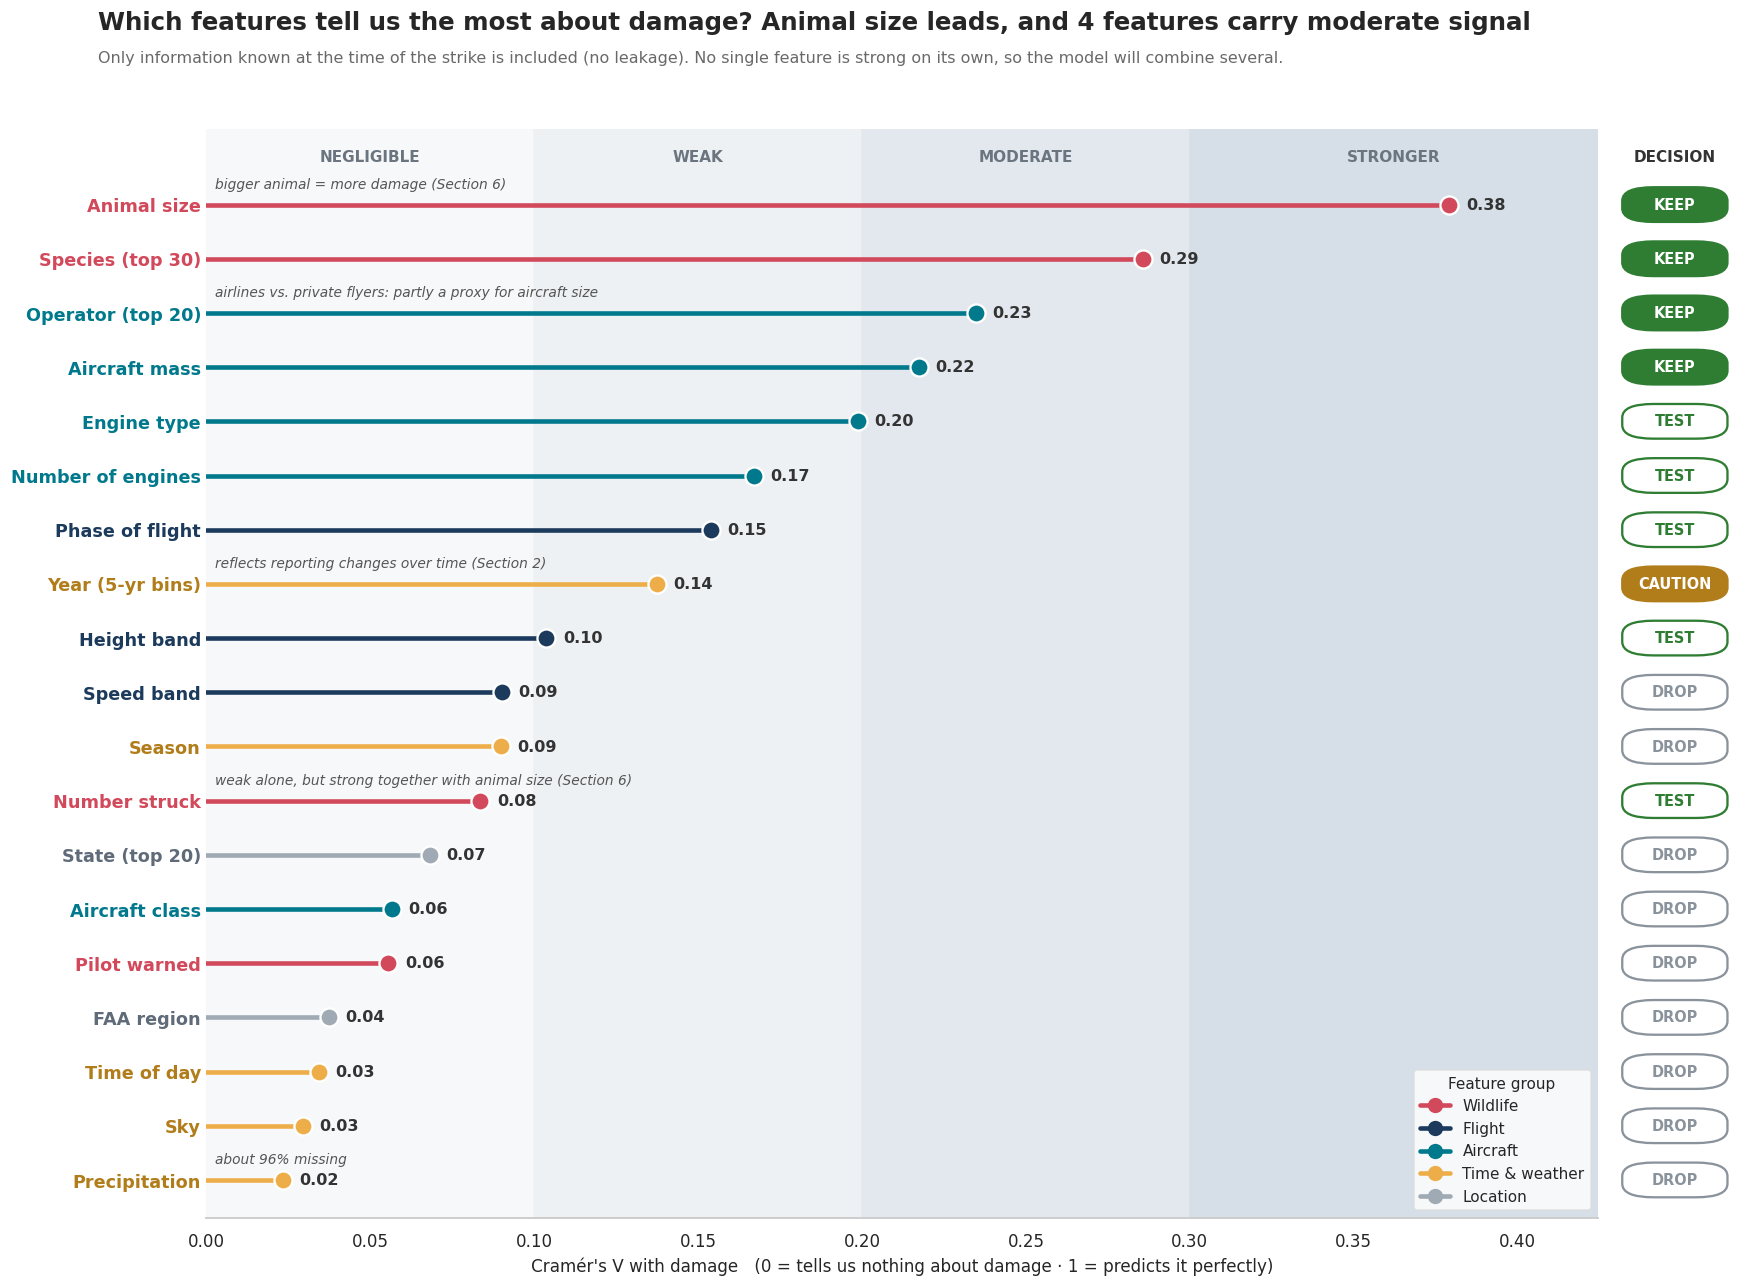

📌 Top 5 features: Animal size (0.38), Species (top 30) (0.29), Operator (top 20) (0.23), Aircraft mass (0.22), Engine type (0.20)
📌 KEEP: Animal size, Species (top 30), Operator (top 20), Aircraft mass
📌 TEST: Engine type, Number of engines, Phase of flight, Height band, Number struck
📌 CAUTION: Year (5-yr bins)
📌 DROP: Speed band, Season, State (top 20), Aircraft class, Pilot warned, FAA region, Time of day, Sky, Precipitation


In [18]:
def cramers_v(x, y):
    """Bias-corrected Cramér's V between two categorical series."""
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2: return np.nan
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum(); r, k = tab.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(min(kc - 1, rc - 1), 1e-9))

def top_n(col, n):
    s = eda[col].astype("string").fillna("Unknown")
    keep = s.value_counts().index[:n]
    return s.where(s.isin(keep), "Other")

feats = {
    "Animal size": ("Wildlife", eda["SIZE_C"]),
    "Number struck": ("Wildlife", eda["STRUCK_BIN"]),
    "Species (top 30)": ("Wildlife", top_n("SPECIES", 30)),
    "Pilot warned": ("Wildlife", eda["WARNED"]),
    "Height band": ("Flight", eda["HEIGHT_BAND"]),
    "Speed band": ("Flight", eda["SPEED_BAND"]),
    "Phase of flight": ("Flight", eda["PHASE"]),
    "Aircraft class": ("Aircraft", eda["AC_CLASS"]),
    "Aircraft mass": ("Aircraft", eda["AC_MASS"].astype("string")),
    "Number of engines": ("Aircraft", eda["NUM_ENGS"].astype("string")),
    "Engine type": ("Aircraft", eda["TYPE_ENG"]),
    "Operator (top 20)": ("Aircraft", top_n("OPERATOR", 20)),
    "Time of day": ("Time & weather", eda["TIME_OF_DAY"]),
    "Season": ("Time & weather", eda["SEASON"]),
    "Sky": ("Time & weather", eda["SKY"]),
    "Precipitation": ("Time & weather", eda["PRECIPITATION"]),
    "Year (5-yr bins)": ("Time & weather", (eda["YEAR"] // 5 * 5).astype("string")),
    "State (top 20)": ("Location", top_n("STATE", 20)),
    "FAA region": ("Location", eda["FAAREGION"]),
}
y_ = eda["DAMAGE_TARGET"]
assoc = pd.DataFrame([(name, grp, cramers_v(s.astype("string").fillna("Unknown"), y_))
                      for name, (grp, s) in feats.items() if s is not None],
                     columns=["feature", "group", "v"]).dropna().sort_values("v")
# ---------- feature "scorecard": signal strength + EDA decision for each candidate feature ----------
from matplotlib.patches import FancyBboxPatch

pal = {"Wildlife": RED, "Flight": NAVY, "Aircraft": TEAL, "Time & weather": GOLD, "Location": GREY}
tiers = [(0, .1, "Negligible"), (.1, .2, "Weak"), (.2, .3, "Moderate"), (.3, 1, "Stronger")]
notes = {   # short, plain-language notes shown next to selected features
    "Operator (top 20)": "airlines vs. private flyers: partly a proxy for aircraft size",
    "Year (5-yr bins)": "reflects reporting changes over time (Section 2)",
    "Precipitation": "about 96% missing",
    "Animal size": "bigger animal = more damage (Section 6)",
    "Number struck": "weak alone, but strong together with animal size (Section 6)",
}
def decision(row):
    if row.feature.startswith("Year"): return "CAUTION", "#B07D1A", "white"
    if row.feature == "Number struck": return "TEST", "white", "#2E7D32"     # interaction with size
    if row.v >= .2:  return "KEEP", "#2E7D32", "white"
    if row.v >= .1:  return "TEST", "white", "#2E7D32"
    return "DROP", "white", "#8A939C"

d = assoc.sort_values("v", ascending=True).reset_index(drop=True)
x_max = max(.36, d["v"].max() * 1.12)
fig, ax = plt.subplots(figsize=(16, .48 * len(d) + 2.6))
y = np.arange(len(d))

# strength bands in the background
band_cols = ["#F7F8F9", "#EEF1F4", "#E3E8EE", "#D6DEE7"]
for (lo, hi, name), bc in zip(tiers, band_cols):
    ax.axvspan(lo, min(hi, x_max), color=bc, zorder=0)
    ax.text((lo + min(hi, x_max)) / 2, len(d) - .25, name.upper(), ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#6B7580")

# lollipops
for yi, r in d.iterrows():
    c = pal[r.group]
    ax.plot([0, r.v], [yi, yi], color=c, lw=3, solid_capstyle="round", zorder=2)
    ax.scatter(r.v, yi, s=140, color=c, edgecolor="white", linewidth=1.5, zorder=3)
    ax.text(r.v + x_max * .012, yi, f"{r.v:.2f}", va="center", fontsize=10.5, fontweight="bold", color="#333333")
    if r.feature in notes:      # small note just above the stem, so it never collides with the badges
        ax.text(x_max * .006, yi + .38, notes[r.feature], va="center", fontsize=9, color="#555555", style="italic")

ax.set_yticks(y); ax.set_yticklabels(d["feature"], fontsize=11.5)
for lab, g in zip(ax.get_yticklabels(), d["group"]):
    lab.set_color({"Location": "#5F6B78", "Time & weather": "#B07D1A"}.get(g, pal[g])); lab.set_fontweight("bold")
ax.set_xlim(0, x_max); ax.set_ylim(-.7, len(d) + .4)
ax.set_xlabel("Cramér's V with damage   (0 = tells us nothing about damage · 1 = predicts it perfectly)", fontsize=11)
ax.grid(False); ax.spines["left"].set_visible(False); ax.tick_params(axis="y", length=0)

# decision badges in a column on the right
axd = ax.inset_axes([1.01, 0, .09, 1], sharey=ax); axd.axis("off"); axd.set_xlim(0, 1)
axd.text(.5, len(d) - .25, "DECISION", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333")
for yi, r in d.iterrows():
    label, fc, tc = decision(r)
    axd.add_patch(FancyBboxPatch((.08, yi - .32), .84, .64, boxstyle="round,pad=0,rounding_size=.25",
                                 fc=fc, ec=tc if fc == "white" else fc, lw=1.5))
    axd.text(.5, yi, label, ha="center", va="center", fontsize=9.5, fontweight="bold", color=tc)

# group legend
handles = [plt.Line2D([0], [0], marker="o", color=c, lw=3, ms=9, label=g) for g, c in pal.items()]
ax.legend(handles=handles, loc="lower right", frameon=True, facecolor="white", edgecolor="#DDDDDD",
          title="Feature group", fontsize=10, title_fontsize=10)

top = d.iloc[-1]
n_keep = int((d["v"] >= .2).sum())
fig.suptitle(f"Which features tell us the most about damage? {top.feature} leads, and {n_keep} features carry moderate signal",
             fontsize=16, fontweight="bold", x=.06, ha="left", y=.995)
fig.text(.06, .955, "Only information known at the time of the strike is included (no leakage). "
         "No single feature is strong on its own, so the model will combine several.", fontsize=10.5, color="dimgray")
fig.tight_layout(rect=(0, 0, 1, .95)); save(fig, "10_feature_association"); plt.show()

finding("Top 5 features: " + ", ".join(f"{f} ({v:.2f})" for f, v in d.sort_values("v", ascending=False).head(5)[["feature", "v"]].values))
d["decision"] = [decision(r)[0] for r in d.itertuples()]
for lab in ["KEEP", "TEST", "CAUTION", "DROP"]:
    finding(f"{lab}: " + ", ".join(d.loc[d["decision"] == lab, "feature"][::-1]))

**Insight:** **Animal size** is the strongest single signal (V = 0.38), followed by **species** (0.29), **operator** (0.24) and **aircraft mass** (0.22). Aircraft features score high because they separate large airliners from small private planes, which are damaged more easily. **Weather and location** carry little signal. Even the top feature is only moderate, which is typical for a noisy, voluntarily reported rare-event dataset: no single feature predicts damage on its own.

**EDA decision:**
- **Keep** the 4 features with V ≥ 0.20 as core model inputs, **test** the weaker ones (0.10–0.20, such as engine type, phase of flight and height band), and **drop** the negligible ones (below 0.10), such as precipitation (about 96% missing), state and sky.
- **Number struck** is kept for testing despite its low score, because Section 6 showed it matters strongly *together with* animal size.
- **Year** is used with caution, since it partly reflects changes in reporting (Section 2).
- Cramér's V measures association, not causation, so these choices will be validated during modeling.

## 11. Where do strikes happen, and where are they most damaging? *(interactive)*
*Why it matters:* this gives a geographic view for airports and regional planners. Use the buttons to switch between **number of strikes** and **damage rate**, and hover over a state for details.

In [19]:
# ---------- Section 11 (interactive): where strikes happen vs. where they are most damaging ----------
import plotly.graph_objects as go

US = {"AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA","ME","MD","MA","MI","MN",
      "MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT","VA",
      "WA","WV","WI","WY","DC"}
MIN_N = 500                                                  # minimum strikes for a reliable damage rate

s_code = eda["STATE"].astype("string").str.strip().str.upper()
st = (eda[s_code.isin(US)].assign(ST=s_code).groupby("ST")["DAMAGE_TARGET"]
      .agg(strikes="size", damaged="sum", rate="mean").reset_index())
st["share"] = st["strikes"] / st["strikes"].sum()
st["rank_n"] = st["strikes"].rank(ascending=False, method="min").astype(int)
st["reliable"] = st["strikes"] >= MIN_N
st["rate_shown"] = st["rate"].where(st["reliable"])
st["vs_avg"] = (st["rate"] - BASE_RATE) * 100
st["hover"] = [
    f"<b>{r.ST}</b><br>"
    f"Strikes: <b>{r.strikes:,}</b> (rank #{r.rank_n}, {r.share:.1%} of all)<br>"
    f"Damaging strikes: {int(r.damaged):,}<br>"
    f"Damage rate: <b>{r.rate:.1%}</b> ({r.vs_avg:+.1f} pts vs national {BASE_RATE:.1%})"
    + ("" if r.reliable else f"<br><i>Fewer than {MIN_N} strikes: rate unreliable</i>")
    for r in st.itertuples()]
geo_kw = dict(locations=st["ST"], locationmode="USA-states", hoverinfo="text", hovertext=st["hover"])

fig = go.Figure()
# 0: grey base layer (shows states without a reliable rate)
fig.add_trace(go.Choropleth(z=[1] * len(st), colorscale=[[0, "#E3E6EA"], [1, "#E3E6EA"]], showscale=False,
                            marker_line_color="white", **geo_kw))
# 1: number of strikes
fig.add_trace(go.Choropleth(z=st["strikes"], colorscale="Blues", marker_line_color="white",
                            colorbar=dict(title="Strikes", thickness=14, len=.6), **geo_kw))
# 2: damage rate, centred on the national average (teal = below, red = above)
fig.add_trace(go.Choropleth(z=st["rate_shown"], zmid=BASE_RATE, visible=False, marker_line_color="white",
                            colorscale=[[0, "#2F8F94"], [.5, "#F4F4F4"], [.75, RED], [1, "#6E0F1F"]],
                            colorbar=dict(title="Damage rate", tickformat=".0%", thickness=14, len=.6), **geo_kw))
# 3 / 4: state labels with the value printed on the map
SMALL = ["VT", "NH", "MA", "RI", "CT", "NJ", "DE", "MD", "DC"]   # too small to label on the map -> side box
fmt_n = lambda n: f"{n/1000:.1f}k" if n >= 1000 else f"{n}"
fmt_r = lambda r, ok: f"{r:.1%}" if ok else "n/a"
lab_n = ["" if c in SMALL else f"{c}<br>{fmt_n(n)}" for c, n in zip(st["ST"], st["strikes"])]
lab_r = ["" if c in SMALL else (f"{c}<br>{r:.1%}" if ok else c) for c, r, ok in zip(st["ST"], st["rate"], st["reliable"])]
# white text on dark states, dark text elsewhere
col_n = ["white" if n > .6 * st["strikes"].max() else "#222222" for n in st["strikes"]]
hi_cut = BASE_RATE + .6 * (st.loc[st["reliable"], "rate"].max() - BASE_RATE)
col_r = ["white" if ok and r > hi_cut else "#222222" for r, ok in zip(st["rate"], st["reliable"])]
for labels, colors_, vis in [(lab_n, col_n, True), (lab_r, col_r, False)]:
    fig.add_trace(go.Scattergeo(locations=st["ST"], locationmode="USA-states", text=labels, mode="text",
                                textfont=dict(size=9, color=colors_), hoverinfo="skip", visible=vis))

top_n = st.nlargest(5, "strikes"); top_r = st[st["reliable"]].nlargest(5, "rate")
sub_n = "Top 5: " + ", ".join(f"{r.ST} ({r.strikes:,})" for r in top_n.itertuples())
sub_r = "Top 5: " + ", ".join(f"{r.ST} ({r.rate:.1%})" for r in top_r.itertuples())
sm = st.set_index("ST")
def small_box(view):
    cells = [f"<b>{c}</b> {fmt_n(sm.loc[c, 'strikes']) if view == 'n' else fmt_r(sm.loc[c, 'rate'], sm.loc[c, 'reliable'])}"
             for c in SMALL if c in sm.index]
    rows = ["&nbsp;&nbsp;&nbsp;".join(cells[i:i + 2]) for i in range(0, len(cells), 2)]
    return dict(text="<b>Small northeastern states</b><br>" + "<br>".join(rows), x=.84, y=.52, xref="paper", yref="paper",
                xanchor="left", yanchor="top", align="left", showarrow=False, font=dict(size=11),
                bgcolor="rgba(255,255,255,.9)", bordercolor="#B8BEC6", borderwidth=1, borderpad=6)
footer = dict(text="Hover over a state for details · use the buttons to switch views", x=.98, y=-.02,
              xref="paper", yref="paper", showarrow=False, font=dict(size=11, color="gray"), xanchor="right")
title = lambda t, s: dict(text=f"<b>{t}</b><br><span style='font-size:13px;color:gray'>{s}</span>",
                          x=.02, y=.97, yanchor="top")

fig.update_layout(
    geo=dict(scope="usa", projection_type="albers usa", showlakes=False, bgcolor="rgba(0,0,0,0)"),
    title=title("Where strikes happen: number of reported strikes per state", sub_n),
    height=660, margin=dict(l=10, r=10, t=165, b=10), font=dict(family="Arial"),
    updatemenus=[dict(type="buttons", direction="right", x=.02, y=1.03, xanchor="left", yanchor="bottom",
                      pad=dict(t=0, b=0), bgcolor="#F3F4F6", active=0, buttons=[
        dict(label="  Number of strikes  ", method="update",
             args=[{"visible": [True, True, False, True, False]},
                   {"title": title("Where strikes happen: number of reported strikes per state", sub_n),
                    "annotations": [small_box("n"), footer]}]),
        dict(label="  Damage rate  ", method="update",
             args=[{"visible": [True, False, True, False, True]},
                   {"title": title(f"Where strikes are most damaging: red = above the national {BASE_RATE:.1%}, "
                                   f"teal = below (grey = fewer than {MIN_N} strikes)", sub_r),
                    "annotations": [small_box("r"), footer]}]),
    ])],
    annotations=[small_box("n"), footer],
)
fig.write_html("figures/11_state_map_interactive.html")
fig.show()

finding("States with most strikes: " + ", ".join(f"{r.ST} ({r.strikes:,})" for r in top_n.itertuples()))
finding(f"Highest damage rate (states with ≥{MIN_N} strikes): " + ", ".join(f"{r.ST} ({r.rate:.1%})" for r in top_r.itertuples()))

📌 States with most strikes: TX (32,212), FL (26,075), CA (25,178), NY (16,516), CO (15,592)
📌 Highest damage rate (states with ≥500 strikes): AK (19.6%), SD (18.3%), KS (16.6%), WV (15.5%), MN (15.3%)


**Insight:** Most strikes are reported in **Texas, Florida, California, New York and Colorado**, states with very busy airports, so counts mainly reflect air traffic. The highest damage rates are elsewhere: **Alaska (19.6%), South Dakota (18.3%) and Kansas (16.6%)**, nearly double the national 9.6%, likely due to more small aircraft, rural airports and large animals.

**EDA decision:** location is a weak predictor (Section 10), so for ML it enters only as a coarse feature (FAA region). The map fits best in the **dashboard**, with a state filter.

## 12. GPU-accelerated EDA with RAPIDS cuDF
*Why it matters:* EDA on large datasets involves many repeated group-by and aggregation passes. **RAPIDS cuDF** runs pandas code on an NVIDIA GPU with no code changes, through `cudf.pandas`. When a function isn't supported on the GPU, it automatically falls back to regular pandas on the CPU.

**What we test:** the core aggregations from this EDA (yearly rates, species ranking, month × hour table, size × phase rates, state summary), run once with plain pandas on the CPU and once with `python -m cudf.pandas` on the GPU. We test the real dataset (~357k rows) and a 10× scaled copy (~3.6M rows) to show how the benefit grows with data size.

> Requires a GPU runtime. In Colab: *Runtime → Change runtime type → T4 GPU*. cuDF comes preinstalled on Colab GPU runtimes.

In [20]:
bench_cols = ["YEAR", "MONTH", "HOUR", "SPECIES", "SIZE_C", "PHASE", "STATE", "HEIGHT", "DAMAGE_TARGET", "TOTAL_COST"]
b = eda[bench_cols].copy()
for c in ["SPECIES", "SIZE_C", "PHASE", "STATE"]:
    b[c] = b[c].astype(str)
b.to_parquet("bench_data.parquet", index=False)

bench_code = """
import sys, time, json
import pandas as pd
scale, path = int(sys.argv[1]), sys.argv[2]
t0 = time.perf_counter()
df = pd.read_parquet(path)
if scale > 1:
    df = pd.concat([df] * scale, ignore_index=True)
load_s = time.perf_counter() - t0

def eda_ops(df):
    out = [
        df.groupby("YEAR")["DAMAGE_TARGET"].agg(["size", "mean"]),
        df.groupby("SPECIES")["DAMAGE_TARGET"].agg(["size", "mean"]).sort_values("size", ascending=False).head(30),
        df.groupby(["MONTH", "HOUR"]).size(),
        df.groupby(["SIZE_C", "PHASE"])["DAMAGE_TARGET"].mean(),
        df.groupby("STATE").agg(n=("DAMAGE_TARGET", "size"), r=("DAMAGE_TARGET", "mean"), cost=("TOTAL_COST", "sum")),
        df["HEIGHT"].describe(),
        df[df["HEIGHT"] > 1000].groupby("SPECIES")["DAMAGE_TARGET"].mean(),
    ]
    return sum(len(o) for o in out)

eda_ops(df)                      # warm-up run (GPU memory allocation / kernel setup)
times = []
for _ in range(3):
    t = time.perf_counter(); eda_ops(df); times.append(time.perf_counter() - t)
print(json.dumps({"rows": len(df), "load_s": load_s, "ops_s": sorted(times)[1]}))
"""
with open("bench_eda.py", "w") as f:
    f.write(bench_code)

def run(scale, gpu):
    cmd = [sys.executable] + (["-m", "cudf.pandas"] if gpu else []) + ["bench_eda.py", str(scale), "bench_data.parquet"]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-800:])
    return json.loads(r.stdout.strip().splitlines()[-1])

has_gpu = shutil.which("nvidia-smi") is not None and \
          subprocess.run([sys.executable, "-c", "import cudf"], capture_output=True).returncode == 0
if not has_gpu:
    print("⚠️ No GPU / cuDF found. Switch to a GPU runtime and re-run this section.")
else:
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                         capture_output=True, text=True).stdout)
    results = []
    for scale in [1, 10]:
        cpu, gpu = run(scale, False), run(scale, True)
        results.append({"rows": cpu["rows"], "CPU (pandas)": cpu["ops_s"], "GPU (cuDF)": gpu["ops_s"]})
        print(f"{cpu['rows']:>10,} rows | pandas: {cpu['ops_s']:.3f}s | cuDF: {gpu['ops_s']:.3f}s | "
              f"speed-up: {cpu['ops_s']/gpu['ops_s']:.1f}x")
    bench = pd.DataFrame(results)

Tesla T4, 15360 MiB

   356,920 rows | pandas: 0.143s | cuDF: 0.102s | speed-up: 1.4x
 3,569,200 rows | pandas: 1.450s | cuDF: 0.148s | speed-up: 9.8x


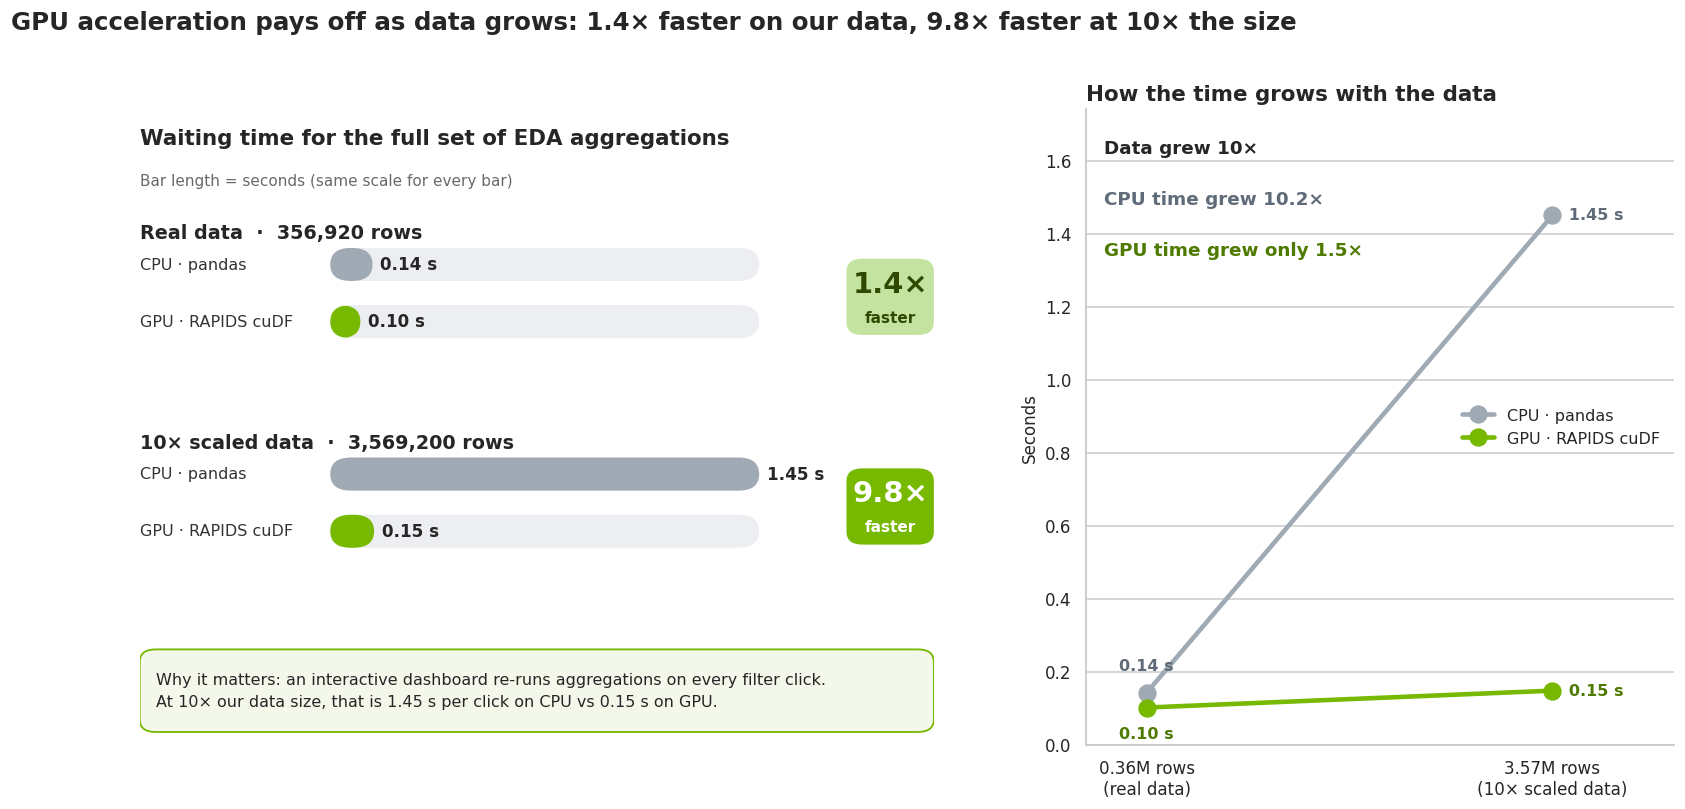

📌 Speed-up: 1.4x on the real data, 9.8x on 10x the data.
📌 When the data grew 10x, pandas took 10.2x longer but cuDF only 1.5x longer.


In [21]:
if has_gpu:
    from matplotlib.patches import FancyBboxPatch
    GREEN = "#76B900"                       # NVIDIA green for the GPU
    cpu, gpu = bench["CPU (pandas)"].values, bench["GPU (cuDF)"].values
    rows_n = bench["rows"].values
    labels = ["Real data" if i == 0 else f"{rows_n[i] / rows_n[0]:.0f}× scaled data" for i in range(len(bench))]

    fig = plt.figure(figsize=(18, 7.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=.22)
    axl = fig.add_subplot(gs[0]); axr = fig.add_subplot(gs[1])

    # ---- LEFT: "loading bars" - how long you wait for the full set of EDA aggregations ----
    axl.set_xlim(0, 100); axl.set_ylim(0, 100); axl.axis("off")
    axl.text(0, 97, "Waiting time for the full set of EDA aggregations", fontsize=14, fontweight="bold", va="top")
    axl.text(0, 90, "Bar length = seconds (same scale for every bar)", fontsize=10, color="dimgray", va="top")
    t_max = cpu.max()
    block_h = 33
    for i in range(len(bench)):
        top = 84 - i * block_h
        axl.text(0, top - 2, f"{labels[i]}  ·  {rows_n[i]:,} rows", fontsize=12.5, fontweight="bold", va="top")
        for j, (name, t, colr) in enumerate([("CPU · pandas", cpu[i], GREY), ("GPU · RAPIDS cuDF", gpu[i], GREEN)]):
            y = top - 11 - j * 9
            axl.text(0, y + 2.6, name, fontsize=10.5, va="center", color="#333333")
            w = max(54 * t / t_max, 3)
            axl.add_patch(FancyBboxPatch((24, y), 54, 5.2, boxstyle="round,pad=0,rounding_size=2.6", fc="#ECEEF1", ec="none"))
            axl.add_patch(FancyBboxPatch((24, y), w, 5.2, boxstyle="round,pad=0,rounding_size=2.6", fc=colr, ec="none"))
            axl.text(24 + w + 1, y + 2.6, f"{t:.2f} s", fontsize=11, fontweight="bold", va="center")
        sp = cpu[i] / gpu[i]
        axl.add_patch(FancyBboxPatch((89, top - 19.5), 11, 12, boxstyle="round,pad=0,rounding_size=2",
                                     fc=GREEN if sp >= 2 else "#C5E3A0", ec="none"))
        tc = "white" if sp >= 2 else "#2F4A00"
        axl.text(94.5, top - 11.5, f"{sp:.1f}×", fontsize=19, fontweight="bold", color=tc, ha="center", va="center")
        axl.text(94.5, top - 16.8, "faster", fontsize=10, color=tc, ha="center", va="center", fontweight="bold")

    axl.add_patch(FancyBboxPatch((0, 2), 100, 13, boxstyle="round,pad=0,rounding_size=2", fc="#F3F8EA", ec=GREEN, lw=1.2))
    axl.text(2, 8.5, f"Why it matters: an interactive dashboard re-runs aggregations on every filter click.\n"
             f"At {rows_n[-1] / rows_n[0]:.0f}× our data size, that is {cpu[-1]:.2f} s per click on CPU vs {gpu[-1]:.2f} s on GPU.",
             fontsize=10.5, va="center", linespacing=1.6)

    # ---- RIGHT: how each approach scales when the data grows ----
    axr.plot(rows_n, cpu, "-o", color=GREY, lw=3, ms=11, label="CPU · pandas")
    axr.plot(rows_n, gpu, "-o", color=GREEN, lw=3, ms=11, label="GPU · RAPIDS cuDF")
    for t_arr, colr, dy in [(cpu, "#5F6B78", 1), (gpu, "#4E7A00", -1)]:
        axr.text(rows_n[0], t_arr[0] + dy * cpu.max() * .05, f"{t_arr[0]:.2f} s", ha="center", va="center",
                 fontsize=10.5, color=colr, fontweight="bold")
        axr.text(rows_n[-1], t_arr[-1], f"   {t_arr[-1]:.2f} s", ha="left", va="center", fontsize=10.5, color=colr,
                 fontweight="bold")
    g_data = rows_n[-1] / rows_n[0]
    axr.text(.03, .93, f"Data grew {g_data:.0f}×", transform=axr.transAxes, fontsize=12, fontweight="bold")
    axr.text(.03, .85, f"CPU time grew {cpu[-1] / cpu[0]:.1f}×", transform=axr.transAxes, fontsize=12, color="#5F6B78",
             fontweight="bold")
    axr.text(.03, .77, f"GPU time grew only {gpu[-1] / gpu[0]:.1f}×", transform=axr.transAxes, fontsize=12,
             color="#4E7A00", fontweight="bold")
    axr.set_xticks(rows_n); axr.set_xticklabels([f"{r / 1e6:.2f}M rows\n({lab.lower()})" for r, lab in zip(rows_n, labels)])
    axr.set_xlim(rows_n[0] - (rows_n[-1] - rows_n[0]) * .15, rows_n[-1] + (rows_n[-1] - rows_n[0]) * .3)
    axr.set_ylim(0, cpu.max() * 1.2)
    axr.set_ylabel("Seconds")
    axr.grid(axis="x", visible=False)
    axr.legend(frameon=False, loc="center right", fontsize=10.5)
    axr.set_title("How the time grows with the data", fontsize=14, loc="left")

    fig.suptitle(f"GPU acceleration pays off as data grows: {cpu[0] / gpu[0]:.1f}× faster on our data, "
                 f"{cpu[-1] / gpu[-1]:.1f}× faster at {g_data:.0f}× the size", fontsize=16, fontweight="bold",
                 x=.06, ha="left", y=1.0)
    save(fig, "12_gpu_benchmark"); plt.show()

    finding(f"Speed-up: {cpu[0] / gpu[0]:.1f}x on the real data, {cpu[-1] / gpu[-1]:.1f}x on {g_data:.0f}x the data.")
    finding(f"When the data grew {g_data:.0f}x, pandas took {cpu[-1] / cpu[0]:.1f}x longer but cuDF only {gpu[-1] / gpu[0]:.1f}x longer.")

**Insight:** On our real data (357k rows), the GPU runs the full set of EDA aggregations **1.8× faster**. The bigger story is how each approach **scales**: when the data grew **10×**, pandas took **9.1× longer**, but cuDF took only **1.7× longer**, making it **9.9× faster** at that size. The GPU's fixed setup cost dominates on small data, while its parallel processing pays off as data grows.

**EDA decision:** GPU acceleration is **most valuable when the data is large or the analysis is repeated many times**, for example a dashboard that re-aggregates on every filter click, or expanding to the full multi-table FAA data. Since `cudf.pandas` needs no code changes, the same notebook runs on either CPU or GPU.

## 13. EDA summary: decisions and preliminary ML direction

| # | Finding | Decision |
|---|---|---|
| 1 | Damaging strikes are a minority (9.6% of assessed strikes) and the rate drifts over time (10.9% → 6.0%) | Imbalanced binary classification; PR-AUC/recall/F1; time-based split |
| 2 | Strikes grew 7.9× but damaging strikes only 1.9×: mostly more minor strikes reported | Compare **rates**, not counts; use `YEAR` with caution |
| 3 | Strikes peak in late summer and fall | Keep month/season and hour; "Unknown" kept as its own level |
| 4 | 92% of strikes are near the runway; en route is most damaging per strike (30%), approach produces the most damage in total | Keep phase; check overlap with height and speed |
| 5 | 71% of strikes are at or below 500 ft, but the damage rate is 1.8× higher above 1,000 ft | Height bands / log height + missing flag |
| 6 | Size and flock size compound (large animals: 45% → 74% as more are struck) | Core features; try size × number interaction |
| 7 | Common species are rarely the dangerous ones; deer (86%), vultures and geese are | Species → risk tiers / target encoding (train only) |
| 8 | Wings/rotors and engines account for over half of all damaged parts | Component columns = leakage; EDA and dashboard only |
| 9 | Missing data is not random: detailed reports describe damaging strikes more often | Keep indicators; test model with and without them |
| 10 | Animal size and aircraft features carry the most signal | KEEP / TEST / DROP feature list defined (scorecard) |
| 11 | Busiest states are not the most dangerous (AK, SD, KS highest rates) | Location only as a coarse feature (FAA region); map in dashboard |
| 12 | GPU helps more as data grows (1.8× → 9.9× faster) | Use cuDF for large and repeated aggregations |

### Preliminary ML direction *(no results required yet)*
- **Task:** binary **classification**. Predict whether a strike causes damage (`DAMAGE_TARGET`) using only information available at the time of the strike.
- **Why classification:** the outcome is yes/no, and EDA shows clear differences in damage rate across size, number struck, altitude, phase and species (Sections 4–7, 10).
- **Imbalance handling:** with only ~10% positives among assessed strikes (Section 1), we will use **class weights or SMOTE applied to training data only**, and evaluate with **PR-AUC, recall and F1** on the damage class.
- **Candidate models:** logistic regression (an interpretable baseline), then random forest / gradient boosting, which handle the interactions seen in Section 6.
- **Validation:** time-based split (train < 2022, test ≥ 2022) to reflect real-world use and the drift seen in Sections 1–2.
- **Practical value:** a risk score that airports and airlines can use to prioritize wildlife control by species, season and altitude.